# Meteorological Indicators, Exposure, and EF Rating in U.S. Tornadoes, 2010–2025

## 1. Study Overview

This study examines how radar indicators, tornado characteristics, and land-cover
exposure proxies relate to recorded EF ratings for U.S. tornadoes from 2010–2025.
Retrospective and onset feature views support the analysis, alongside controlled
neural-network experiments.

- **Primary question:** How do meteorology, tornado characteristics, and exposure
  relate to final EF rating?
- **Secondary question:** How well can final EF rating be estimated using
  features eligible by reported onset?
- **Modeling question:** How do learning rate, SGD, L2 regularization, and
  dropout affect training, generalization, and overfitting?

EF is a damage-based rating, not a direct wind measurement.

## 2. Setup

In [1]:
# Python 3.12+. Uncomment to install dependencies in this notebook kernel.
# %pip install geopandas joblib kagglehub matplotlib numpy pandas pyarrow scikit-learn jinja2 ipykernel tensorflow
# NVIDIA GPU on Linux/WSL2: %pip install 'tensorflow[and-cuda]>=2.21.0'
# Restart the kernel after installation.

import hashlib
import json
import os
import random
import textwrap
from collections.abc import Mapping, Sequence
from dataclasses import asdict, dataclass, replace
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
from typing import TYPE_CHECKING, Literal, TypedDict

# Paths are relative to the notebook kernel's working folder.
BASE_DIR = Path.cwd()

os.environ.setdefault("MPLCONFIGDIR", str(BASE_DIR / "data/.cache/matplotlib"))

import geopandas as gpd
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import Markdown, display
from matplotlib.cm import ScalarMappable
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.figure import Figure
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.transforms import Bbox
from numpy.typing import NDArray
from shapely.geometry import Polygon
from shapely.geometry import box as geometry_box
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, log_loss, precision_recall_fscore_support
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Reset these seeds and the TensorFlow seed before each later training run.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Keep CPU resource use modest; reset random seeds before each model.
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(1)
tf.config.experimental.enable_op_determinism()

# tf.keras loads lazily; use the matching public Keras types for static checks.
if TYPE_CHECKING:
    import keras
else:
    from tensorflow import keras

I0000 00:00:1789591150.185890  315598 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789591150.229173  315598 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789591150.991810  315598 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
DATASET = "jakevanslyke/us-tornado-data-2010-2025/versions/8"
RELEASE = "v2.2.1"
MANIFEST_SHA256 = "9a4ec9b89cbf43cdfa88db26360881aab84437fee619f1b98e1fb04a338f8feb"
DATA_DIR = BASE_DIR / "data"
SOURCE_DIR = DATA_DIR / "source/v8"
DERIVED_DIR = DATA_DIR / "derived"
RESULTS_DIR = DATA_DIR / "results"
AUDIT_DIR = RESULTS_DIR / "audit"
FIGURE_DIR = BASE_DIR / "assets/figures"
TABLE_DIR = BASE_DIR / "assets/tables"

for directory in (SOURCE_DIR, DERIVED_DIR, AUDIT_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ML_FILES = (
    "ml/events_onset.parquet",
    "ml/events_retrospective.parquet",
    "ml/feature_dictionary.json",
)

MAP_FILES = (
    "analysis/county_boundaries.parquet",
    "analysis/event_areas.parquet",
    "analysis/tornado_footprints.parquet",
)

SPLIT_ORDER = ["train", "validation", "test"]
SPLIT_FRACTIONS = np.array([0.70, 0.15, 0.15])
SPLIT_CANDIDATES = 512
CLASS_NAMES = [f"EF{i}" for i in range(6)]
N_CLASSES = len(CLASS_NAMES)
EVALUATION_SETTINGS = {
    "class_labels": list(range(N_CLASSES)),
    "selection_metric": "validation macro-F1",
    "metrics": [
        "accuracy",
        "cross_entropy",
        "macro_f1",
        "per_class_precision",
        "per_class_recall",
        "per_class_f1",
        "class_support",
        "confusion_matrix",
        "ef_category_mae",
        "within_one_category_accuracy",
    ],
    "prediction_rule": "argmax of six class probabilities",
    "undefined_class_metric": "zero_division=0; explicitly report absent classes and support",
    "evaluation_weighting": "unweighted validation and test metrics",
    "test_policy": "evaluate each final selected task model once; never select using test scores",
}

In [3]:
EF_ORDER = ["EF0", "EF1", "EF2", "EF3", "EF4", "EF5", "Unknown"]
EF_COLORS = dict(
    zip(
        EF_ORDER,
        ["#F2C94C", "#F29E38", "#ED6A32", "#D93632", "#AD203E", "#650026", "#999999"],
        strict=True,
    )
)
ACCENT = "#0072B2"

plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.axisbelow": True,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "svg.fonttype": "none",
    }
)

In [4]:
def show_saved(description: str, *paths: Path, status: str = "Saved") -> None:
    """Show links only after the files exist."""
    links = []
    for path in map(Path, paths):
        assert path.is_file(), path
        relative = path.relative_to(BASE_DIR).as_posix()
        links.append(f"[{path.name}]({relative})")
    display(Markdown(f"**{status} — {description}:** " + " · ".join(links)))


def save_json(value: object, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + "\n")


def save_figure(fig: Figure, name: str, directory: Path = FIGURE_DIR) -> None:
    for extension in ("png", "svg"):
        path = directory / f"{name}.{extension}"
        fig.savefig(path, bbox_inches="tight")
        if extension == "svg":
            path.write_text(
                "\n".join(line.rstrip() for line in path.read_text().splitlines()) + "\n"
            )


def save_table(
    frame: pd.DataFrame,
    name: str,
    title: str,
    *,
    caption: str,
    formats: Mapping[str, str] | None = None,
    note: str | None = None,
    width: float = 9,
    results_dir: Path = AUDIT_DIR,
) -> None:
    """Save numeric CSV plus a legible, consistently styled table image."""
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)
    frame.to_csv(results_dir / f"{name}.csv", index=False)
    shown = frame.copy()
    for column, pattern in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value, pattern=pattern: "—" if pd.isna(value) else format(value, pattern)
        )
    shown = shown.fillna("—").astype(str)
    note_lines = textwrap.wrap(note, width=110) if note else []
    height = 0.34 * (len(frame) + 1.5) + 0.65 + 0.18 * len(note_lines)
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis("off")
    fig.text(0.03, 1 - 0.22 / height, title, fontsize=12, weight="bold", va="top")
    headers = [textwrap.fill(str(c), width=22) for c in frame.columns]
    column_widths = np.array(
        [
            max(max(map(len, header.splitlines())), shown[column].str.len().max()) + 3
            for column, header in zip(frame.columns, headers, strict=True)
        ],
        dtype=float,
    )
    table = ax.table(
        cellText=shown.values.tolist(),
        colLabels=headers,
        colWidths=column_widths / column_widths.sum(),
        cellLoc="right",
        colLoc="left",
        bbox=Bbox.from_bounds(0, 0, 1, 1),
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#D6DEE5")
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor("#E7EEF4")
            cell.set_text_props(weight="bold", color="#172B3A")
            cell.set_height(cell.get_height() * 1.5)
        else:
            cell.set_facecolor("#F6F8FA" if row % 2 == 0 else "white")
        if col == 0:
            cell.set_text_props(ha="left")
    if note_lines:
        fig.text(0.03, 0.03, "\n".join(note_lines), fontsize=9, color="#46535F")
    fig.subplots_adjust(
        left=0.03,
        right=0.97,
        top=1 - 0.55 / height,
        bottom=(0.16 + 0.22 * len(note_lines)) / height,
    )
    save_figure(fig, name, TABLE_DIR)
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    show_saved(
        title, TABLE_DIR / f"{name}.png", TABLE_DIR / f"{name}.svg", results_dir / f"{name}.csv"
    )


def file_sha256(path: Path) -> str:
    with Path(path).open("rb") as stream:
        return hashlib.file_digest(stream, "sha256").hexdigest()


def show_figure(fig: Figure, name: str, caption: str) -> None:
    """Save, display, caption, and link a finished analysis figure."""
    save_figure(fig, name)
    plt.show()
    display(Markdown(caption))
    plt.close(fig)
    show_saved("figure", FIGURE_DIR / f"{name}.png", FIGURE_DIR / f"{name}.svg")

In [5]:
# Shared data-preparation helpers.
class HoldoutSplit(TypedDict):
    candidate: int
    score: float
    indices: list[NDArray[np.int64]]


def stratified_group_holdout(
    labels: NDArray[np.int64],
    groups: NDArray[np.object_],
    *,
    fractions: NDArray[np.float64],
    class_count: int,
    seed: int,
    candidates: int,
) -> HoldoutSplit:
    """Balance class allocations and row counts across seeded whole-group splits."""
    class_totals = np.bincount(labels, minlength=class_count)
    best: HoldoutSplit | None = None
    generator = GroupShuffleSplit(n_splits=candidates, test_size=0.30, random_state=seed)
    for trial, (training, held_out) in enumerate(generator.split(labels, labels, groups)):
        validation, test = next(
            GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=seed + trial).split(
                held_out, labels[held_out], groups[held_out]
            )
        )
        indices = [training, held_out[validation], held_out[test]]
        counts = np.array([np.bincount(labels[index], minlength=class_count) for index in indices])
        complete = bool((counts > 0).all())
        # Selection uses labels/group sizes only, never features or model performance.
        class_error = np.mean((counts / class_totals - fractions[:, None]) ** 2)
        size_error = np.mean((counts.sum(axis=1) / len(labels) - fractions) ** 2)
        score = float(class_error + size_error)
        if complete and (best is None or score < best["score"]):
            best = {"candidate": trial, "score": score, "indices": indices}
    if best is None:
        raise ValueError(
            "No group-disjoint allocation supports all six classes. Review the split design."
        )
    return best


def encode_predictors(
    frame: pd.DataFrame,
    columns: list[str],
    *,
    log_columns: list[str],
) -> pd.DataFrame:
    """Apply fixed calendar and log transforms without estimating parameters."""
    encoded = frame[columns].copy()
    encoded["hour_utc"] = frame["onset_utc"].dt.hour.astype(float)
    for column, period, offset in [("month", 12, 1), ("hour_utc", 24, 0)]:
        angle = 2 * np.pi * (encoded.pop(column).astype(float) - offset) / period
        encoded[f"{column}_sin"] = np.sin(angle)
        encoded[f"{column}_cos"] = np.cos(angle)
    for column in set(log_columns) & set(columns):
        assert encoded[column].dropna().ge(0).all(), column
        encoded[column] = np.log1p(encoded[column])
    return encoded.astype(float)


def prepare_inputs(
    split_frames: Mapping[str, pd.DataFrame],
    labels: Mapping[str, pd.Series],
) -> tuple[Pipeline, dict[str, pd.DataFrame]]:
    """Fit on training rows, then transform each split without refitting."""
    train_features = split_frames["train"]
    assert not train_features.isna().all().any(), "A training predictor is entirely missing."
    preprocessor = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
            ("scaler", StandardScaler()),
        ]
    )
    preprocessor.fit(train_features)
    feature_names = preprocessor.get_feature_names_out().tolist()
    prepared_splits = {}
    for split, frame in split_frames.items():
        prepared = pd.DataFrame(
            preprocessor.transform(frame).astype("float32"),
            index=frame.index,
            columns=feature_names,
        )
        assert prepared.index.equals(labels[split].index)
        assert np.isfinite(prepared.to_numpy()).all()
        prepared_splits[split] = prepared
    imputer, scaler = preprocessor["imputer"], preprocessor["scaler"]
    assert scaler.n_samples_seen_ == len(train_features)
    np.testing.assert_allclose(imputer.statistics_, train_features.median().to_numpy())
    np.testing.assert_allclose(prepared_splits["train"].mean(), 0, atol=1e-5)
    return preprocessor, prepared_splits

In [6]:
# Geographic helpers use projected coordinates; the modeling cohort is untouched.
def geographic_bins(
    events: gpd.GeoDataFrame,
    boundaries: gpd.GeoDataFrame,
    *,
    hex_width_m: float,
) -> tuple[gpd.GeoDataFrame, tuple[float, float, float, float]]:
    """Count event starts in equal-area hexagons and return their map extent."""
    bounds = np.vstack([boundaries.total_bounds, events.total_bounds])
    low = bounds[:, :2].min(axis=0) - hex_width_m
    high = bounds[:, 2:].max(axis=0) + hex_width_m
    step = np.array([hex_width_m, np.sqrt(3) * hex_width_m])
    origin = np.floor(low / step) * step
    grid = np.ceil((high - origin) / step).astype(int)
    upper = origin + grid * step
    extent = (float(origin[0]), float(upper[0]), float(origin[1]), float(upper[1]))
    scratch, axis = plt.subplots()
    counts = axis.hexbin(
        events.geometry.x,
        events.geometry.y,
        gridsize=(int(grid[0]), int(grid[1])),
        extent=extent,
        mincnt=1,
    )
    frequencies = counts.get_array()
    assert frequencies is not None
    centers = np.asarray(counts.get_offsets())
    vertices = counts.get_paths()[0].vertices
    cells = gpd.GeoDataFrame(
        {
            "region": "Contiguous U.S.",
            "center_x_m": centers[:, 0],
            "center_y_m": centers[:, 1],
            "events": frequencies.astype(int),
        },
        geometry=[Polygon(vertices + center) for center in centers],
        crs=events.crs,
    )
    plt.close(scratch)
    assert cells.events.sum() == len(events)
    np.testing.assert_allclose(cells.area, np.sqrt(3) / 2 * hex_width_m**2, rtol=1e-7)

    return cells, extent


def plot_geographic_distribution(
    events: gpd.GeoDataFrame,
    boundaries: gpd.GeoDataFrame,
    cells: gpd.GeoDataFrame,
    extent: tuple[float, float, float, float],
    *,
    class_names: Sequence[str],
    colors: Mapping[str, str],
) -> Figure:
    """Overlay six-class event locations on a separate frequency scale."""
    # Frequency has its own scale; point opacity only softens overlap.
    breaks = [1, 5, 10, 20, 40, max(41, int(cells.events.max()) + 1)]
    frequency_labels = ["1–4", "5–9", "10–19", "20–39", "40+"]
    cmap = ListedColormap(plt.get_cmap("Greys")(np.linspace(0.10, 0.45, 5)))
    norm = BoundaryNorm(breaks, cmap.N, clip=True)
    fig, ax = plt.subplots(figsize=(12, 8), layout="constrained")
    boundaries.plot(ax=ax, color="#FAFAFA", edgecolor="none")
    cells.plot(ax=ax, column="events", cmap=cmap, norm=norm, edgecolor="none")
    boundaries.boundary.plot(ax=ax, color="#89939C", linewidth=0.45)
    mapped_known = 0
    for rating, label in enumerate(class_names):
        selected = events.loc[events[TARGET].eq(rating)]
        ax.scatter(
            selected.geometry.x,
            selected.geometry.y,
            s=6,
            alpha=0.70,
            color=colors[label],
            linewidths=0,
            zorder=3 + rating,
        )
        mapped_known += len(selected)
    assert mapped_known == int(events.target_known.sum())
    ax.set(xlim=extent[:2], ylim=extent[2:])
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title("Recorded tornado frequency and EF rating, 2010–2025", pad=14)
    ax.legend(
        handles=[
            Line2D([], [], marker="o", linestyle="", markersize=6, color=colors[label], label=label)
            for label in class_names
        ],
        loc="lower left",
        frameon=False,
        ncol=3,
        title="Final EF rating",
    )
    bar = fig.colorbar(
        ScalarMappable(norm=norm, cmap=cmap),
        ax=ax,
        orientation="horizontal",
        shrink=0.65,
        pad=0.02,
        aspect=40,
    )
    bar.set_ticks(
        ((np.asarray(breaks[:-1]) + np.asarray(breaks[1:])) / 2).tolist(), labels=frequency_labels
    )
    bar.set_label("All recorded events per 50-km hexagon")
    return fig

## 3. Data

[US Tornado Data, 2010–2025](https://www.kaggle.com/datasets/jakevanslyke/us-tornado-data-2010-2025/versions/8)
provides matching retrospective and onset tables. Check their consistency and summarize
**class balance and geographic distribution**, retaining unknown ratings in the audit.
A compact missingness summary accompanies the saved predictor-level counts.

Exposure initially means retrospective land-cover measures. Missing radar maxima can
reflect no qualifying detection; missing warning lead time can reflect no active warning.
Completed collection jobs do not guarantee usable observations. Maps show the contiguous
U.S.; the modeling cohort retains all regions.

### Download

In [7]:
def ensure_source_file(relative_path: str, expected_sha256: str) -> Path:
    destination = SOURCE_DIR / relative_path
    # Reuse local files; output_dir bypasses the global Kaggle cache.
    if not destination.is_file():
        kagglehub.dataset_download(DATASET, path=relative_path, output_dir=str(SOURCE_DIR))
    actual = file_sha256(destination)
    if actual != expected_sha256:
        raise ValueError(
            f"Checksum mismatch for {relative_path}. Inspect the local file and "
            "release before removing it and rerunning the download cell."
        )
    return destination


manifest_path = ensure_source_file("release_manifest.json", MANIFEST_SHA256)
manifest = json.loads(manifest_path.read_text())
assert manifest["version"] == RELEASE
release_files = {entry["path"]: entry for entry in manifest["files"]}

verified_files = []
for relative_path in (*ML_FILES, *MAP_FILES):
    entry = release_files[relative_path]
    path = ensure_source_file(relative_path, entry["sha256"])
    assert path.stat().st_size == entry["bytes"], relative_path
    verified_files.append(
        {
            "path": relative_path,
            "bytes": path.stat().st_size,
            "sha256": entry["sha256"],
        }
    )

save_json(
    {
        "dataset_handle": DATASET,
        "dataset_url": f"https://www.kaggle.com/datasets/{DATASET}",
        "release": RELEASE,
        "source_code_commit": manifest["code_commit"],
        "release_manifest_sha256": MANIFEST_SHA256,
        "files": verified_files,
    },
    SOURCE_DIR / "provenance.json",
)

show_saved(
    "source files (downloaded or reused)",
    SOURCE_DIR / "release_manifest.json",
    *(SOURCE_DIR / name for name in (*ML_FILES, *MAP_FILES)),
    status="Verified",
)
show_saved("data source and file verification", SOURCE_DIR / "provenance.json")

**Verified — source files (downloaded or reused):** [release_manifest.json](data/source/v8/release_manifest.json) · [events_onset.parquet](data/source/v8/ml/events_onset.parquet) · [events_retrospective.parquet](data/source/v8/ml/events_retrospective.parquet) · [feature_dictionary.json](data/source/v8/ml/feature_dictionary.json) · [county_boundaries.parquet](data/source/v8/analysis/county_boundaries.parquet) · [event_areas.parquet](data/source/v8/analysis/event_areas.parquet) · [tornado_footprints.parquet](data/source/v8/analysis/tornado_footprints.parquet)

**Saved — data source and file verification:** [provenance.json](data/source/v8/provenance.json)

### Load data

In [8]:
onset = pd.read_parquet(SOURCE_DIR / "ml/events_onset.parquet")
retrospective = pd.read_parquet(SOURCE_DIR / "ml/events_retrospective.parquet")
spec = json.loads((SOURCE_DIR / "ml/feature_dictionary.json").read_text())

ID, TARGET, GROUP = spec["id"], spec["target"], spec["group"]
tables = {"Onset": onset, "Retrospective": retrospective}
# Use the dictionary allowlists; numeric metadata is not a predictor.
predictors = {
    "Onset": spec["onset_predictor_columns"],
    "Retrospective": spec["retrospective_predictor_columns"],
}

### Validation

In [9]:
assert spec["schema_version"] == 2
expected_rows = manifest["source_verification"]["counts"]["spc_tracks"]
for view, frame in tables.items():
    assert len(frame) == expected_rows, view
    assert frame[ID].notna().all() and frame[ID].is_unique, view
    assert frame[GROUP].notna().all(), view
    assert frame["target_known"].notna().all(), view
    assert frame["target_known"].eq(frame[TARGET].notna()).all(), view
    assert frame[TARGET].dropna().isin(range(6)).all(), view
    assert frame["year"].between(manifest["start_year"], manifest["end_year"]).all()
    assert frame["onset_utc"].notna().all(), view
    assert frame["prediction_cutoff_utc"].eq(frame["onset_utc"]).all(), view
    columns = predictors[view]
    assert len(columns) == len(set(columns)), view
    assert set(columns).issubset(frame.columns), view
    assert all(
        spec["columns"][c]["role"] in {"onset_predictor_candidate", "retrospective_candidate"}
        for c in columns
    ), view
    numeric = frame[columns].select_dtypes(include="number")
    assert not np.isinf(numeric.to_numpy(dtype=float, na_value=np.nan)).any(), view

assert set(predictors["Onset"]).issubset(predictors["Retrospective"])
assert not any(c.startswith("post_") for c in predictors["Onset"])
assert all(spec["columns"][c]["eligible_for_conditional_onset"] for c in predictors["Onset"])
assert all(spec["columns"][c]["available_by_onset"] is None for c in predictors["Onset"])
pd.testing.assert_frame_equal(
    onset.set_index(ID).sort_index(),
    retrospective.set_index(ID).sort_index()[onset.columns.drop(ID)],
)

### Data summary

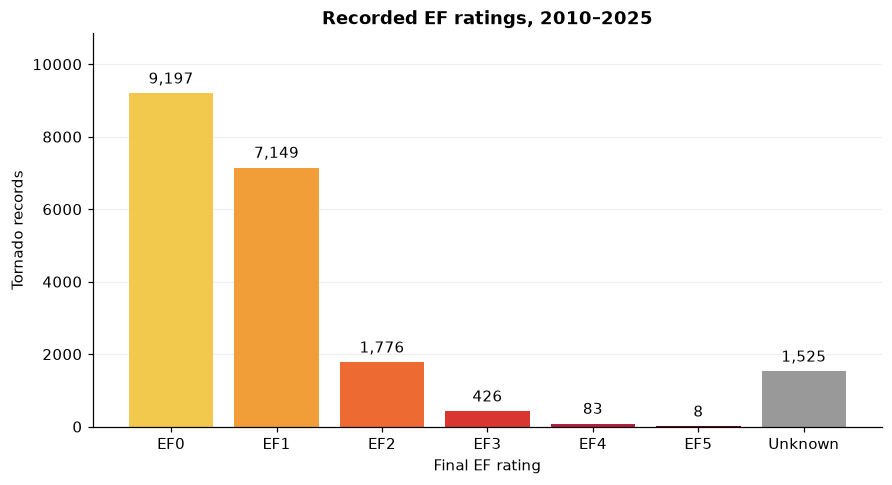

**Figure 1.** Distribution of recorded EF ratings, 2010–2025.

**Saved — figure:** [fig_01_class_distribution.png](assets/figures/fig_01_class_distribution.png) · [fig_01_class_distribution.svg](assets/figures/fig_01_class_distribution.svg)

In [10]:
rating_labels = onset[TARGET].map({i: f"EF{i}" for i in range(6)}).fillna("Unknown")
class_counts = rating_labels.value_counts().reindex(EF_ORDER, fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4.3), layout="constrained")
bars = ax.bar(EF_ORDER, class_counts, color=[EF_COLORS[c] for c in EF_ORDER])
ax.bar_label(bars, labels=[f"{n:,}" for n in class_counts], padding=4, fontsize=10)
ax.set(title="Recorded EF ratings, 2010–2025", ylabel="Tornado records", xlabel="Final EF rating")
ax.set_ylim(0, class_counts.max() * 1.18)
ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_01_class_distribution",
    "**Figure 1.** Distribution of recorded EF ratings, 2010–2025.",
)

In [11]:
missingness_rows = []
for view, frame in tables.items():
    missing = frame[predictors[view]].isna().sum()
    missingness_rows.extend(
        {
            "view": view,
            "feature": column,
            "missing_events": int(count),
            "total_events": len(frame),
            "missing_percent": 100 * count / len(frame),
        }
        for column, count in missing.items()
    )

missingness = pd.DataFrame(missingness_rows)
missingness.to_csv(AUDIT_DIR / "feature_missingness.csv", index=False)

missingness_summary = missingness.groupby("view", sort=False).agg(
    predictors=("feature", "size"),
    incomplete_predictors=("missing_events", lambda counts: int(counts.gt(0).sum())),
    largest_missing_percent=("missing_percent", "max"),
)
display(
    Markdown(
        f"**Data checks passed:** {len(onset):,} matching events per view; "
        f"{onset.target_known.sum():,} known ratings and {(~onset.target_known).sum():,} unknown ratings."
    )
)
display(missingness_summary.style.format({"largest_missing_percent": "{:.1f}%"}))
show_saved("missingness for each predictor in both views", AUDIT_DIR / "feature_missingness.csv")

**Data checks passed:** 20,164 matching events per view; 18,639 known ratings and 1,525 unknown ratings.

,predictors,incomplete_predictors,largest_missing_percent
view,,,
Onset,15,6,65.8%
Retrospective,32,15,65.8%


**Saved — missingness for each predictor in both views:** [feature_missingness.csv](data/results/audit/feature_missingness.csv)

### Geographic coverage

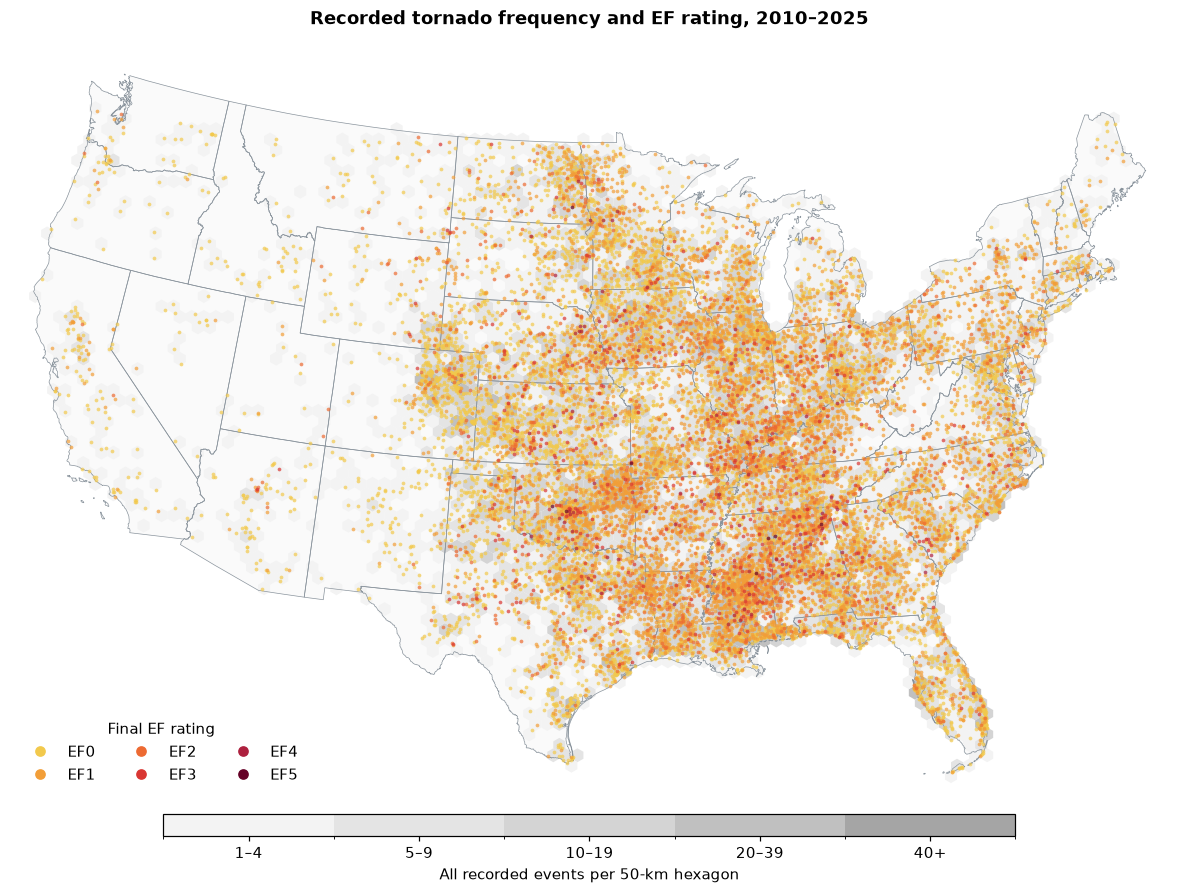

**Figure 2.** Contiguous-U.S. event starts, colored separately for EF0–EF5, over recorded counts in equal-area hexagons approximately 50 km across. Stronger ratings are drawn last; overlap can hide points. Unknown ratings contribute to counts only. These are catalog counts, not estimates of local tornado risk.

**Saved — figure:** [fig_02_geographic_distribution.png](assets/figures/fig_02_geographic_distribution.png) · [fig_02_geographic_distribution.svg](assets/figures/fig_02_geographic_distribution.svg)

In [12]:
counties = gpd.read_parquet(SOURCE_DIR / "analysis/county_boundaries.parquet")
event_areas = gpd.read_parquet(SOURCE_DIR / "analysis/event_areas.parquet").set_index(ID)
assert event_areas.index.is_unique and set(event_areas.index) == set(onset[ID])
map_events = onset[[ID, TARGET, "start_longitude", "start_latitude", "target_known"]].copy()
map_events["state_fips"] = map_events[ID].map(event_areas["state_fips"])
# Restrict the displayed maps only; the modeling cohort remains unchanged.
conus_mask = ~map_events.state_fips.isin(["02", "15", "60", "66", "69", "72", "78"])
map_events = map_events.loc[conus_mask].copy()
assert map_events[["start_longitude", "start_latitude", "state_fips"]].notna().all().all()
events = gpd.GeoDataFrame(
    map_events,
    geometry=gpd.points_from_xy(map_events.start_longitude, map_events.start_latitude),
    crs="EPSG:4326",
).to_crs("EPSG:5070")
boundaries = counties.loc[
    counties.state_fips.isin(map_events.state_fips), ["state_fips", "geometry"]
]
boundaries = boundaries.dissolve("state_fips").to_crs(events.crs)
cells, extent = geographic_bins(events, boundaries, hex_width_m=50_000)
fig = plot_geographic_distribution(
    events,
    boundaries,
    cells,
    extent,
    class_names=CLASS_NAMES,
    colors=EF_COLORS,
)
show_figure(
    fig,
    "fig_02_geographic_distribution",
    "**Figure 2.** Contiguous-U.S. event starts, colored separately for EF0–EF5, over recorded counts in equal-area hexagons approximately 50 km across. Stronger ratings are drawn last; overlap can hide points. Unknown ratings contribute to counts only. These are catalog counts, not estimates of local tornado risk.",
)

## 4. Analysis Preparation

Preserve **EF0–EF5** and use a shared, group-aware stratified random split targeting
**70% training, 15% validation, and 15% testing**. Keep linked events together and
exclude unknown ratings from supervised analysis. Report achieved class support;
class weights cannot compensate for the limited independent EF5 examples.

Explore training relationships before preparing the two feature views. Encode month
and hour cyclically and log-transform selected skewed predictors. Fit median imputation,
missingness indicators, scaling, and class weights on **training data only**, using the
same rules and event assignments for both views. Reserve test scoring for final models.

Section 5 compares ordinal models, partial balancing, and loss weighting on this fixed split.
A temporal split and focal ordinal loss remain later robustness checks. The Oklahoma footprint is a supporting illustration of track geometry.
Saved outputs are linked below their corresponding results.

### Cohort and target

In [13]:
PREPARATION_DIR = RESULTS_DIR / "preparation"
PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
eligible = onset.loc[onset.target_known].reset_index(drop=True)
ratings = eligible[TARGET].to_numpy(dtype=int)
group_ids = eligible[GROUP].to_numpy()


chosen_split = stratified_group_holdout(
    ratings,
    group_ids,
    fractions=SPLIT_FRACTIONS,
    class_count=N_CLASSES,
    seed=SEED,
    candidates=SPLIT_CANDIDATES,
)
split_lookup = pd.Series(
    {
        event_id: split
        for split, indices in zip(SPLIT_ORDER, chosen_split["indices"], strict=True)
        for event_id in eligible.iloc[indices][ID]
    }
)
assignments = onset[[ID, GROUP, "onset_utc", "target_known"]].copy()
assignments["eligible"] = assignments.target_known
assignments["split"] = assignments[ID].map(split_lookup).fillna("excluded")
assignments["exclusion_reason"] = np.where(assignments.target_known, "", "unknown_label")
assert assignments.loc[assignments.target_known, "split"].isin(SPLIT_ORDER).all()
assert assignments.loc[~assignments.target_known, "split"].eq("excluded").all()
assignments.to_parquet(DERIVED_DIR / "split_assignments.parquet", index=False)
split_ids = {
    split: assignments.loc[assignments.split.eq(split), ID].tolist() for split in SPLIT_ORDER
}
split_groups = {
    split: set(assignments.loc[assignments.split.eq(split), GROUP]) for split in SPLIT_ORDER
}
for i, first in enumerate(SPLIT_ORDER):
    for second in SPLIT_ORDER[i + 1 :]:
        assert set(split_ids[first]).isdisjoint(split_ids[second])
        assert split_groups[first].isdisjoint(split_groups[second])
assert sum(map(len, split_ids.values())) == len(eligible)
indexed_tables = {view: frame.set_index(ID) for view, frame in tables.items()}
cohorts = {
    view: {split: frame.loc[split_ids[split]].copy() for split in SPLIT_ORDER}
    for view, frame in indexed_tables.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_series_equal(
        cohorts["Onset"][split][TARGET], cohorts["Retrospective"][split][TARGET]
    )
    assert set(cohorts["Onset"][split][TARGET].unique()) == set(range(N_CLASSES))

split_summary = pd.DataFrame(
    [
        {
            "Split": split.title(),
            "Target (%)": 100 * fraction,
            "Events": len(split_ids[split]),
            "Actual (%)": 100 * len(split_ids[split]) / len(eligible),
            "Groups": len(split_groups[split]),
        }
        for split, fraction in zip(SPLIT_ORDER, SPLIT_FRACTIONS, strict=True)
    ]
)
save_json(
    {
        "method": "seeded group-random candidate search with class stratification objective",
        "seed": SEED,
        "candidate_count": SPLIT_CANDIDATES,
        "chosen_candidate": chosen_split["candidate"],
        "balance_score": chosen_split["score"],
        "selection_basis": "equal-weight class-allocation MSE plus row-allocation MSE; all six classes required",
        "target_fractions": dict(zip(SPLIT_ORDER, SPLIT_FRACTIONS.tolist(), strict=True)),
        "unknown_labels_excluded": int((~assignments.target_known).sum()),
        "retained_events": {s: len(ids) for s, ids in split_ids.items()},
        "retained_groups": {s: len(groups) for s, groups in split_groups.items()},
        "group_overlap": False,
    },
    PREPARATION_DIR / "split_summary.json",
)
save_json(EVALUATION_SETTINGS, DERIVED_DIR / "evaluation_config.json")
show_saved(
    f"{len(eligible):,} labeled events assigned to disjoint groups across splits",
    DERIVED_DIR / "split_assignments.parquet",
    PREPARATION_DIR / "split_summary.json",
)
show_saved("metrics and held-out evaluation rules", DERIVED_DIR / "evaluation_config.json")

**Saved — 18,639 labeled events assigned to disjoint groups across splits:** [split_assignments.parquet](data/derived/split_assignments.parquet) · [split_summary.json](data/results/preparation/split_summary.json)

**Saved — metrics and held-out evaluation rules:** [evaluation_config.json](data/derived/evaluation_config.json)

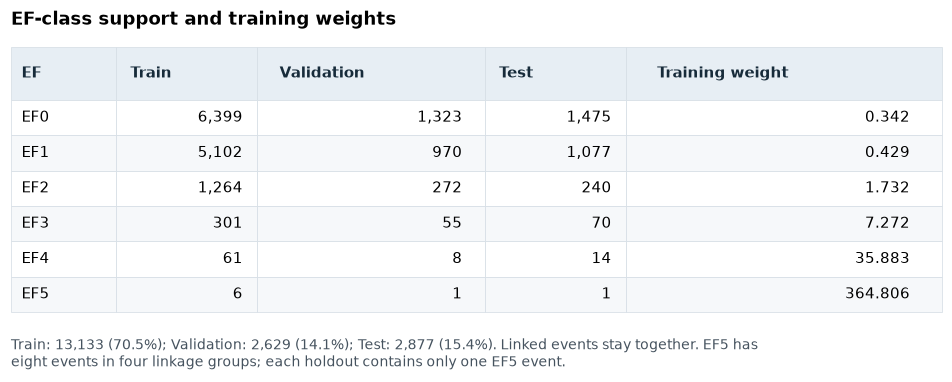

**Table 1.** Shared split assignments and reference weights for the full-data softmax baseline.

**Saved — EF-class support and training weights:** [table_01_class_support.png](assets/tables/table_01_class_support.png) · [table_01_class_support.svg](assets/tables/table_01_class_support.svg) · [table_01_class_support.csv](data/results/preparation/table_01_class_support.csv)

**Saved — aligned labels for train, validation, and test:** [labels_train.parquet](data/derived/labels_train.parquet) · [labels_validation.parquet](data/derived/labels_validation.parquet) · [labels_test.parquet](data/derived/labels_test.parquet)

**Saved — six-class target definition and training weights:** [target_definition.json](data/derived/target_definition.json) · [class_weights.json](data/derived/class_weights.json)

In [14]:
class_support = pd.DataFrame(
    {
        split.title(): cohorts["Onset"][split][TARGET]
        .value_counts()
        .reindex(range(N_CLASSES), fill_value=0)
        for split in SPLIT_ORDER
    }
)
support_table = class_support.rename_axis("EF").reset_index()
support_table["EF"] = support_table.EF.map(lambda rating: CLASS_NAMES[rating])
TARGET_MAPPING = {rating: rating for rating in range(N_CLASSES)}
y = {
    split: cohorts["Onset"][split][TARGET].astype("int64").rename("target_class")
    for split in SPLIT_ORDER
}
for split in SPLIT_ORDER:
    assert set(y[split].unique()) == set(range(N_CLASSES))
    pd.concat([cohorts["Onset"][split][TARGET], y[split]], axis=1).to_parquet(
        DERIVED_DIR / f"labels_{split}.parquet"
    )
save_json(
    {
        "source_target": TARGET,
        "mapping": {str(k): v for k, v in TARGET_MAPPING.items()},
        "class_names": CLASS_NAMES,
        "n_classes": N_CLASSES,
        "rationale": "Preserve each original EF category; class collapsing is not the default.",
        "unknown_labels": "excluded from supervised learning, retained in coverage summaries",
        "candidate_outputs": "six-class softmax or five ordered cumulative logits",
        "candidate_losses": "weighted categorical CE; ordinal threshold BCE with optional weighting",
        "selection_metric_for_later_models": "validation macro-F1 across all six labels",
        "rare_class_limitation": "Class weighting does not create additional independent EF5 evidence.",
    },
    DERIVED_DIR / "target_definition.json",
)

class_weights = dict(
    zip(
        range(N_CLASSES),
        compute_class_weight(
            class_weight="balanced", classes=np.arange(N_CLASSES), y=y["train"].to_numpy()
        ).tolist(),
        strict=True,
    )
)
save_json(
    {
        "strategy": "reference weights for the full-data softmax baseline",
        "weights": {str(k): v for k, v in class_weights.items()},
        "formula": "n_training / (n_classes * class_training_count)",
        "policy": "Section 5 freezes selected sampling/weighting for controlled comparisons; holdouts unweighted",
    },
    DERIVED_DIR / "class_weights.json",
)

support_table["Training weight"] = [class_weights[i] for i in range(N_CLASSES)]
split_note = "; ".join(
    f"{row['Split']}: {row['Events']:,} ({row['Actual (%)']:.1f}%)"
    for row in split_summary.to_dict("records")
)
save_table(
    support_table,
    "table_01_class_support",
    "EF-class support and training weights",
    caption="**Table 1.** Shared split assignments and reference weights for the full-data softmax baseline.",
    formats={**{split.title(): ",d" for split in SPLIT_ORDER}, "Training weight": ".3f"},
    note=split_note + ". Linked events stay together. EF5 has eight events in four linkage groups; "
    "each holdout contains only one EF5 event.",
    width=9,
    results_dir=PREPARATION_DIR,
)

show_saved(
    "aligned labels for train, validation, and test",
    *(DERIVED_DIR / f"labels_{split}.parquet" for split in SPLIT_ORDER),
)
show_saved(
    "six-class target definition and training weights",
    DERIVED_DIR / "target_definition.json",
    DERIVED_DIR / "class_weights.json",
)

### Training-data exploration

In [15]:
train = cohorts["Retrospective"]["train"]
train_numeric = train[predictors["Retrospective"]].select_dtypes(include="number")
training_skew = train_numeric.skew()

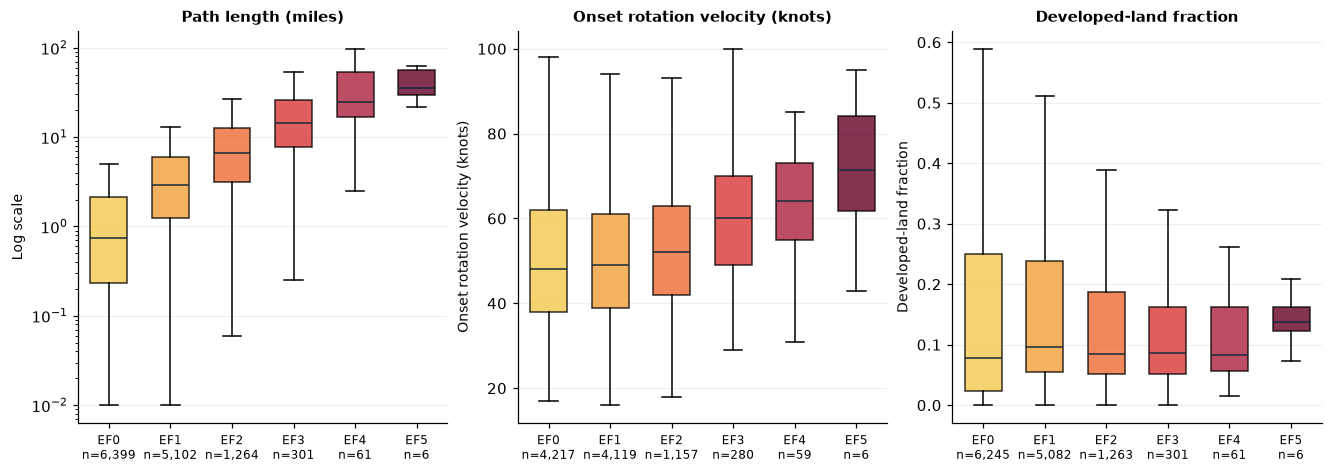

**Figure 3.** Training predictors by original EF rating. Boxes show medians and interquartile ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed values for that feature; rare-class and missing-data patterns limit interpretation.

**Saved — figure:** [fig_03_training_relationships.png](assets/figures/fig_03_training_relationships.png) · [fig_03_training_relationships.svg](assets/figures/fig_03_training_relationships.svg)

In [16]:
relationship_features = [
    ("post_path_length_miles", "Path length (miles)", True),
    ("radar_max_rotation_velocity_knots", "Onset rotation velocity (knots)", False),
    ("post_land_developed_fraction", "Developed-land fraction", False),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2), layout="constrained")
for ax, (feature, label, log_axis) in zip(axes.flat, relationship_features, strict=True):
    values = [
        train.loc[train[TARGET].eq(ef), feature].dropna().to_numpy(dtype=float) for ef in range(6)
    ]
    boxes = ax.boxplot(
        values,
        tick_labels=[f"EF{ef}\nn={len(v):,}" for ef, v in enumerate(values)],
        patch_artist=True,
        showfliers=False,
        widths=0.6,
    )
    for ef, box in enumerate(boxes["boxes"]):
        box.set_facecolor(EF_COLORS[f"EF{ef}"])
        box.set_alpha(0.8)
    for median in boxes["medians"]:
        median.set_color("#172B3A")
    if log_axis:
        ax.set_yscale("log")
    ax.set_title(label, fontsize=10)
    ax.set_ylabel("Log scale" if log_axis else label, fontsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.grid(axis="y", alpha=0.2)
show_figure(
    fig,
    "fig_03_training_relationships",
    "**Figure 3.** Training predictors by original EF rating. Boxes show medians and interquartile ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed values for that feature; rare-class and missing-data patterns limit interpretation.",
)

### Feature preparation

In [17]:
feature_groups = {
    "Location and timing": ["start_longitude", "start_latitude", "month", "hour_utc"],
    "Onset radar": [c for c in predictors["Onset"] if c.startswith("radar_")],
    "Warnings": [c for c in predictors["Onset"] if c.startswith("warning_")],
    "Final track": [
        "post_end_longitude",
        "post_end_latitude",
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
    ],
    "Full-window radar": [c for c in predictors["Retrospective"] if c.startswith("post_radar_")],
    "Land cover": [
        c
        for c in predictors["Retrospective"]
        if c.startswith("post_land_") or c == "post_impervious_mean_percent"
    ],
}
group_columns = [c for columns in feature_groups.values() for c in columns]
assert len(group_columns) == len(set(group_columns))
assert set(group_columns) == set(predictors["Retrospective"])

group_summary = pd.DataFrame(
    [
        {
            "Feature group": group,
            "Onset": len(set(columns) & set(predictors["Onset"])),
            "Retrospective": len(columns),
        }
        for group, columns in feature_groups.items()
    ]
)

# The source stores hour 0–23 as epoch nanoseconds; derive hours from onset_utc.
for frame in tables.values():
    assert pd.api.types.is_datetime64_any_dtype(frame["hour_utc"])
    encoded_hour = frame["hour_utc"].astype("int64")
    assert encoded_hour.between(0, 23).all()
    np.testing.assert_array_equal(encoded_hour, frame["onset_utc"].dt.hour)
    np.testing.assert_array_equal(frame["month"], frame["onset_utc"].dt.month)

log_candidates = [
    c
    for c in predictors["Retrospective"]
    if ("radar_" in c and c.endswith("_count"))
    or c
    in [
        "post_path_length_miles",
        "post_path_width_yards",
        "post_duration_minutes",
        "post_impervious_mean_percent",
    ]
]
LOG_COLUMNS = [c for c in log_candidates if training_skew[c] > 1]
assert train[LOG_COLUMNS].min().ge(0).all()


encoded = {
    view: {
        split: encode_predictors(frame, predictors[view], log_columns=LOG_COLUMNS)
        for split, frame in split_frames.items()
    }
    for view, split_frames in cohorts.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_frame_equal(
        encoded["Onset"][split],
        encoded["Retrospective"][split][encoded["Onset"][split].columns],
    )
predictor_definition = {
    "raw_columns": predictors,
    "groups": feature_groups,
    "encoded_columns": {view: frame["train"].columns.tolist() for view, frame in encoded.items()},
    "log1p_columns": LOG_COLUMNS,
    "log_selection": "nonnegative count/track/impervious candidates with training skew > 1",
    "calendar_encoding": "month and UTC hour replaced by sine/cosine pairs",
    "hour_correction": "derive numeric hour from onset_utc; verified against stored epoch-nanosecond values",
    "source_files_modified": False,
}
save_json(predictor_definition, DERIVED_DIR / "predictor_sets.json")
show_saved(
    f"feature definitions, cyclic time encoding, and {len(LOG_COLUMNS)} log transforms",
    DERIVED_DIR / "predictor_sets.json",
)

**Saved — feature definitions, cyclic time encoding, and 10 log transforms:** [predictor_sets.json](data/derived/predictor_sets.json)

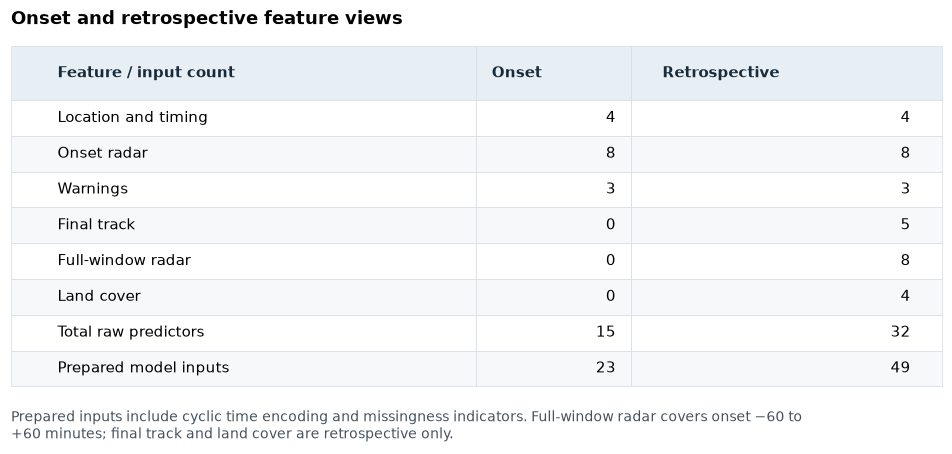

**Table 2.** Feature-group counts and final input dimensions for the same event cohort.

**Saved — Onset and retrospective feature views:** [table_02_feature_views.png](assets/tables/table_02_feature_views.png) · [table_02_feature_views.svg](assets/tables/table_02_feature_views.svg) · [table_02_feature_views.csv](data/results/preparation/table_02_feature_views.csv)

**Saved — Onset inputs — 23 columns; train: 13,133 rows, validation: 2,629 rows, test: 2,877 rows:** [onset_train.parquet](data/derived/onset_train.parquet) · [onset_validation.parquet](data/derived/onset_validation.parquet) · [onset_test.parquet](data/derived/onset_test.parquet)

**Saved — Retrospective inputs — 49 columns; train: 13,133 rows, validation: 2,629 rows, test: 2,877 rows:** [retrospective_train.parquet](data/derived/retrospective_train.parquet) · [retrospective_validation.parquet](data/derived/retrospective_validation.parquet) · [retrospective_test.parquet](data/derived/retrospective_test.parquet)

**Saved — fitted training-only imputation and scaling pipelines:** [onset_preprocessor.joblib](data/derived/onset_preprocessor.joblib) · [retrospective_preprocessor.joblib](data/derived/retrospective_preprocessor.joblib)

**Saved — preprocessing settings and input column order:** [preprocessing_config.json](data/derived/preprocessing_config.json)

In [18]:
preprocessors: dict[str, Pipeline] = {}
X: dict[str, dict[str, pd.DataFrame]] = {}
for view, split_frames in encoded.items():
    preprocessor, prepared_splits = prepare_inputs(split_frames, y)
    preprocessors[view], X[view] = preprocessor, prepared_splits
    for split, prepared in prepared_splits.items():
        prepared.to_parquet(DERIVED_DIR / f"{view.lower()}_{split}.parquet")
    joblib.dump(preprocessor, DERIVED_DIR / f"{view.lower()}_preprocessor.joblib")

save_json(
    {
        "fit_split": "train",
        "imputation": "training median",
        "missing_indicators": "columns with missing values in training",
        "scaling": "training mean and standard deviation, including indicators",
        "raw_predictors": predictors,
        "log1p_columns": LOG_COLUMNS,
        "input_columns": {
            view: split_frames["train"].columns.tolist() for view, split_frames in X.items()
        },
        "training_id_sha256": hashlib.sha256("\n".join(split_ids["train"]).encode()).hexdigest(),
        "sklearn_version": version("scikit-learn"),
        "split_method": "group-aware stratified random holdout",
        "seed": SEED,
    },
    DERIVED_DIR / "preprocessing_config.json",
)

view_summary = pd.concat(
    [
        group_summary.rename(columns={"Feature group": "Feature / input count"}),
        pd.DataFrame(
            [
                {
                    "Feature / input count": "Total raw predictors",
                    **{view: len(columns) for view, columns in predictors.items()},
                },
                {
                    "Feature / input count": "Prepared model inputs",
                    **{view: frames["train"].shape[1] for view, frames in X.items()},
                },
            ]
        ),
    ],
    ignore_index=True,
)
save_table(
    view_summary,
    "table_02_feature_views",
    "Onset and retrospective feature views",
    caption="**Table 2.** Feature-group counts and final input dimensions for the same event cohort.",
    formats={"Onset": "d", "Retrospective": "d"},
    width=9,
    note="Prepared inputs include cyclic time encoding and missingness indicators. Full-window radar "
    "covers onset −60 to +60 minutes; final track and land cover are retrospective only.",
    results_dir=PREPARATION_DIR,
)

for view, frames in X.items():
    sizes = ", ".join(f"{split}: {len(frames[split]):,} rows" for split in SPLIT_ORDER)
    show_saved(
        f"{view} inputs — {frames['train'].shape[1]} columns; {sizes}",
        *(DERIVED_DIR / f"{view.lower()}_{split}.parquet" for split in SPLIT_ORDER),
    )
show_saved(
    "fitted training-only imputation and scaling pipelines",
    *(DERIVED_DIR / f"{view.lower()}_preprocessor.joblib" for view in X),
)
show_saved(
    "preprocessing settings and input column order", DERIVED_DIR / "preprocessing_config.json"
)

### Supporting event illustration

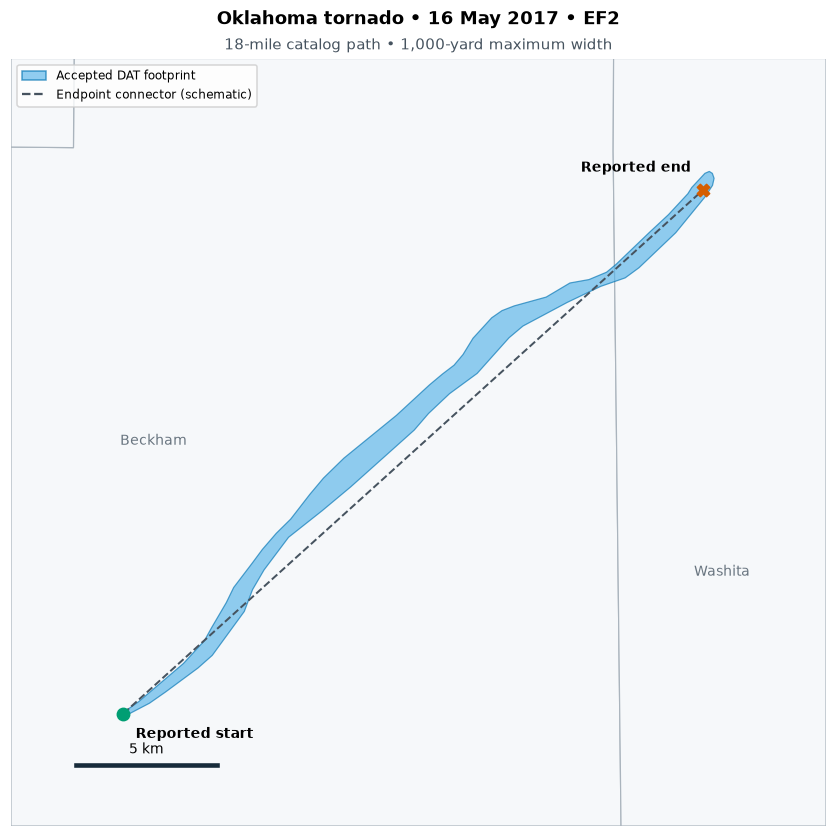

**Figure 4 (supporting).** Training event `spc:2017:1705161746-01` and its accepted DAT footprint. The dashed connector joins SPC start/end coordinates; it is not a surveyed centerline. The footprint does not show a time-resolved trajectory or local EF changes. This fixed Oklahoma example is illustrative and was not used to choose the split or model settings.

**Saved — figure:** [fig_04_example_event_footprint.png](assets/figures/fig_04_example_event_footprint.png) · [fig_04_example_event_footprint.svg](assets/figures/fig_04_example_event_footprint.svg)

In [19]:
footprints = gpd.read_parquet(SOURCE_DIR / "analysis/tornado_footprints.parquet").set_index(
    "footprint_id"
)
assert footprints.index.is_unique
# Keep the previously illustrated event; it must belong to the shared training split.
example_id = "spc:2017:1705161746-01"
assert example_id in split_ids["train"]
example = train.loc[example_id]
area = event_areas.loc[[example_id]]
footprint_ids = area.iloc[0].footprint_ids.tolist()
assert area.iloc[0].area_method == "union_of_accepted_footprints"
assert example_id in split_ids["train"] and area.iloc[0].state_fips == "40"
local_crs = area.estimate_utm_crs()
footprint = footprints.loc[footprint_ids].to_crs(local_crs)
endpoints = gpd.GeoSeries(
    gpd.points_from_xy(
        [example.start_longitude, example.post_end_longitude],
        [example.start_latitude, example.post_end_latitude],
    ),
    crs="EPSG:4326",
).to_crs(local_crs)
assert not endpoints.is_empty.any()
all_bounds = np.vstack([footprint.total_bounds, endpoints.total_bounds])
low, high = all_bounds[:, :2].min(axis=0) - 4_000, all_bounds[:, 2:].max(axis=0) + 4_000
window = geometry_box(*low, *high)
local_counties = counties.loc[counties.state_fips.isin(area.iloc[0].area_states)].to_crs(local_crs)
local_counties = local_counties.clip(window)

fig, ax = plt.subplots(figsize=(8, 7.5), layout="constrained")
local_counties.plot(ax=ax, color="#F6F8FA", edgecolor="#AAB4BD", linewidth=0.8)
for _, county in local_counties.iterrows():
    if county.geometry.area < window.area * 0.03:
        continue
    label_area = county.geometry.difference(footprint.geometry.union_all().buffer(1_500))
    center = label_area.representative_point()
    ax.text(center.x, center.y, county.county_name, ha="center", fontsize=9, color="#697580")
footprint.plot(ax=ax, color="#56B4E9", alpha=0.65, edgecolor=ACCENT, linewidth=0.8)
ax.plot(endpoints.x, endpoints.y, "--", color="#46535F", linewidth=1.3)
ax.scatter(endpoints.x.iloc[0], endpoints.y.iloc[0], color="#009E73", s=65, marker="o", zorder=5)
ax.scatter(endpoints.x.iloc[1], endpoints.y.iloc[1], color="#D55E00", s=65, marker="X", zorder=5)
for i, label in enumerate(["Reported start", "Reported end"]):
    ax.annotate(
        label,
        (endpoints.x.iloc[i], endpoints.y.iloc[i]),
        xytext=(8, -16) if i == 0 else (-8, 12),
        textcoords="offset points",
        ha="left" if i == 0 else "right",
        fontsize=9,
        weight="bold",
    )
bar_x, bar_y = low + (high - low) * [0.08, 0.08]
ax.plot([bar_x, bar_x + 5_000], [bar_y, bar_y], color="#172B3A", linewidth=3)
ax.text(bar_x + 2_500, bar_y + 400, "5 km", ha="center", fontsize=9)
ax.set(xlim=(low[0], high[0]), ylim=(low[1], high[1]))
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title(
    f"{example.post_path_length_miles:.0f}-mile catalog path • "
    f"{example.post_path_width_yards:,.0f}-yard maximum width",
    fontsize=10,
    weight="normal",
    color="#46535F",
)
ax.legend(
    handles=[
        Patch(facecolor="#56B4E9", edgecolor=ACCENT, alpha=0.65, label="Accepted DAT footprint"),
        Line2D([0], [0], color="#46535F", linestyle="--", label="Endpoint connector (schematic)"),
    ],
    loc="upper left",
    frameon=True,
    fontsize=8,
)
state_name = counties.loc[counties.state_fips.eq(area.iloc[0].state_fips), "state_name"].iloc[0]
fig.suptitle(
    f"{state_name} tornado • {example.onset_utc:%d %B %Y} • EF{int(example[TARGET])}", weight="bold"
)
show_figure(
    fig,
    "fig_04_example_event_footprint",
    f"**Figure 4 (supporting).** Training event `{example_id}` and its accepted DAT footprint. The dashed connector joins SPC start/end coordinates; it is not a surveyed centerline. The footprint does not show a time-resolved trajectory or local EF changes. This fixed Oklahoma example is illustrative and was not used to choose the split or model settings.",
)

## 5. Modeling and Research Experiments

Start with a weighted softmax baseline, then compare a single ordinal network,
a full-data ordinal ensemble, a partially balanced ordinal ensemble, and that same
subset ensemble with gentler class weighting. Each network has three ReLU hidden
layers (**128 → 64 → 32**), trained for **50 epochs** with batches of **64**.
Ordinal models learn five ordered thresholds, **P(EF > k)**; averaging member
probabilities preserves all six final EF categories. The softmax reference is class-weighted;
the single ordinal model is unweighted, so that pair changes both formulation and weighting.

Three ensemble members use fixed seeds and training subsets. Partial balancing caps
EF0 and EF1 at the training EF2 count, retaining every EF2–EF5 training record.
The weighted ordinal variant uses inverse-square-root class counts from each subset,
normalized to mean sample weight one. Validation retains its original distribution.
These are cumulative ordinal networks with explicitly ordered cutpoints, informed by
[rank-consistent ordinal regression](https://arxiv.org/abs/1901.07884), and a multiclass
neural-network adaptation of [subset ensembling](https://cs.nju.edu.cn/zhouzh/zhouzh.files/publication/tsmcb09.pdf).

Select the strategy by final-epoch **validation macro F1**, breaking ties with
six-class predictive cross-entropy. Then address:

- **Modeling question:** hold the selected formulation, sampling, member seeds, and
  weighting fixed while comparing SGD learning rates, L2, and dropout.
- **Primary question:** hold the selected training approach fixed while removing
  retrospective radar, final-track, and land-cover feature groups.
- **Secondary question:** retrain the same approach using only onset-eligible predictors.

Curves score averaged probabilities on the full training and validation cohorts;
optimization losses are reported separately. Report total optimizer updates and runtime
because equal epochs do not imply equal compute. No test scoring occurs here. These
are exploratory comparisons from one split and one fixed set of member seeds, not
independent repetitions; one validation EF5 event limits confidence in rankings.

In [20]:
# Ordinal heads model P(EF > k) with ordered cutpoints, k = 0, ..., 4.
@keras.utils.register_keras_serializable(package="Tornado")
class OrderedLogits(keras.layers.Layer):
    def build(self, input_shape: tuple[int | None, ...]) -> None:
        self.first = self.add_weight(name="first", shape=(), initializer="zeros")
        self.gaps = self.add_weight(name="gaps", shape=(N_CLASSES - 2,), initializer="zeros")
        super().build(input_shape)

    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        offsets = tf.concat([tf.zeros((1,)), tf.cumsum(tf.nn.softplus(self.gaps))], axis=0)
        return inputs - (self.first + offsets)[None, :]


@keras.utils.register_keras_serializable(package="Tornado")
class OrdinalProbabilities(keras.layers.Layer):
    def call(self, inputs: tf.Tensor) -> tf.Tensor:
        above = tf.math.sigmoid(inputs)
        return tf.concat([1 - above[:, :1], above[:, :-1] - above[:, 1:], above[:, -1:]], axis=1)


@keras.utils.register_keras_serializable(package="Tornado")
def ordinal_cross_entropy(labels: tf.Tensor, logits: tf.Tensor) -> tf.Tensor:
    levels = tf.cast(tf.reshape(labels, (-1, 1)), tf.int32) > tf.range(N_CLASSES - 1)
    losses = tf.nn.sigmoid_cross_entropy_with_logits(
        labels=tf.cast(levels, logits.dtype), logits=logits
    )
    return tf.reduce_mean(losses, axis=1)


@dataclass(frozen=True)
class ExperimentConfig:
    name: str
    formulation: Literal["softmax", "ordinal"] = "ordinal"
    members: int = 1
    sampling: Literal["full", "partial"] = "full"
    weighting: Literal["none", "balanced", "sqrt"] = "none"
    optimizer: Literal["Adam", "SGD"] = "Adam"
    learning_rate: float = 0.001
    l2: float = 0.0
    dropout: float = 0.0


class MemberRecord(TypedDict):
    member: int
    seed: int
    training_rows: int
    class_counts: list[int]
    class_weights: list[float]
    initial_weights_sha256: str
    sample_sha256: str
    optimizer_steps: int


@dataclass
class ExperimentResult:
    config: ExperimentConfig
    models: list[keras.Model]
    histories: list[keras.callbacks.History]
    epochs: pd.DataFrame
    member_epochs: pd.DataFrame
    members: list[MemberRecord]
    seconds: float
    completed: bool


def build_model(n_features: int, config: ExperimentConfig, *, seed: int) -> keras.Model:
    model = keras.Sequential([keras.layers.Input(shape=(n_features,))], name=f"member_{seed}")
    for index, units in enumerate((128, 64, 32)):
        model.add(
            keras.layers.Dense(
                units,
                activation="relu",
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + index),
                kernel_regularizer=keras.regularizers.l2(config.l2) if config.l2 else None,
            )
        )
        if index < 2 and config.dropout:
            model.add(keras.layers.Dropout(config.dropout, seed=seed + 100 + index))
    if config.formulation == "ordinal":
        model.add(
            keras.layers.Dense(
                1,
                use_bias=False,
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + 3),
            )
        )
        model.add(OrderedLogits())
        loss = ordinal_cross_entropy
    else:
        model.add(
            keras.layers.Dense(
                N_CLASSES,
                activation="softmax",
                kernel_initializer=keras.initializers.GlorotUniform(seed=seed + 3),
            )
        )
        loss = keras.losses.SparseCategoricalCrossentropy()
    optimizer = (
        keras.optimizers.Adam(config.learning_rate)
        if config.optimizer == "Adam"
        else keras.optimizers.SGD(config.learning_rate)
    )
    model.compile(optimizer=optimizer, loss=loss)
    return model


def class_probabilities(
    model: keras.Model, features: NDArray[np.float32], formulation: str
) -> NDArray[np.float32]:
    output = model(features, training=False)
    if formulation == "ordinal":
        output = OrdinalProbabilities()(output)
    return np.asarray(output.numpy(), dtype="float32")


def prediction_metrics(
    labels: NDArray[np.int64], probabilities: NDArray[np.float32]
) -> dict[str, float]:
    if not np.isfinite(probabilities).all():
        return dict.fromkeys(
            ["accuracy", "cross_entropy", "macro_f1", "ef_mae", "within_one"], float("nan")
        )
    assert probabilities.min() >= -1e-7
    np.testing.assert_allclose(probabilities.sum(axis=1), 1, atol=2e-6)
    predictions = probabilities.argmax(axis=1)
    scored = probabilities.astype("float64")
    scored /= scored.sum(axis=1, keepdims=True)
    error = np.abs(predictions - labels)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "cross_entropy": float(log_loss(labels, scored, labels=range(N_CLASSES))),
        "macro_f1": float(
            f1_score(labels, predictions, labels=range(N_CLASSES), average="macro", zero_division=0)
        ),
        "ef_mae": float(error.mean()),
        "within_one": float((error <= 1).mean()),
    }


def sample_training_rows(
    labels: NDArray[np.int64], *, sampling: str, seed: int
) -> NDArray[np.int64]:
    if sampling == "full":
        return np.arange(len(labels), dtype="int64")
    # Cap EF0/EF1 at the training EF2 count; never downsample EF2–EF5.
    cap = int((labels == 2).sum())
    rng = np.random.default_rng(seed)
    selected = []
    for rating in range(N_CLASSES):
        indices = np.flatnonzero(labels == rating)
        if rating < 2 and len(indices) > cap:
            indices = rng.choice(indices, size=cap, replace=False)
        selected.append(indices)
    return np.sort(np.concatenate(selected)).astype("int64")


def training_weights(labels: NDArray[np.int64], weighting: str) -> NDArray[np.float32]:
    counts = np.bincount(labels, minlength=N_CLASSES)
    assert (counts > 0).all()
    exponent = {"none": 0.0, "sqrt": 0.5, "balanced": 1.0}[weighting]
    weights = counts.astype(float) ** -exponent
    weights /= weights[labels].mean()
    return weights.astype("float32")


def training_dataset(
    features: NDArray[np.float32],
    labels: NDArray[np.int64],
    *,
    batch_size: int,
    seed: int,
    weights: NDArray[np.float32] | None = None,
) -> tf.data.Dataset:
    values = (features, labels) if weights is None else (features, labels, weights[labels])
    dataset = tf.data.Dataset.from_tensor_slices(values)
    if weights is not None:
        dataset = dataset.shuffle(len(labels), seed=seed, reshuffle_each_iteration=True)
    options = tf.data.Options()
    options.deterministic = True
    options.threading.private_threadpool_size = 1
    return dataset.batch(batch_size).with_options(options).prefetch(1)


class EpochPredictions(keras.callbacks.Callback):
    """Accumulate member probabilities so curves describe the actual ensemble."""

    def __init__(
        self,
        features: Mapping[str, NDArray[np.float32]],
        formulation: str,
        totals: dict[str, NDArray[np.float32]],
    ) -> None:
        super().__init__()
        self.features, self.formulation, self.totals = features, formulation, totals

    def on_epoch_end(self, epoch: int, logs: dict[str, float] | None = None) -> None:
        assert self.model is not None
        for split, features in self.features.items():
            self.totals[split][epoch] += class_probabilities(self.model, features, self.formulation)


def train_experiment(
    config: ExperimentConfig,
    features: Mapping[str, NDArray[np.float32]],
    labels: Mapping[str, NDArray[np.int64]],
    *,
    epochs: int,
    batch_size: int,
    seed: int,
) -> ExperimentResult:
    started = perf_counter()
    keras.backend.clear_session()
    totals = {
        split: np.zeros((epochs, len(features[split]), N_CLASSES), dtype="float32")
        for split in ("train", "validation")
    }
    models, histories, member_records, member_frames = [], [], [], []
    completed = True
    validation = training_dataset(
        features["validation"], labels["validation"], batch_size=batch_size, seed=seed
    )
    for member in range(config.members):
        member_seed = seed + 1000 * member
        keras.utils.set_random_seed(member_seed)
        rows = sample_training_rows(labels["train"], sampling=config.sampling, seed=member_seed)
        sampled_y = labels["train"][rows]
        weights = training_weights(sampled_y, config.weighting)
        model = build_model(features["train"].shape[1], config, seed=member_seed)
        digest = hashlib.sha256(b"".join(w.tobytes() for w in model.get_weights())).hexdigest()
        training = training_dataset(
            features["train"][rows],
            sampled_y,
            batch_size=batch_size,
            seed=member_seed,
            weights=weights,
        )
        history = model.fit(
            training,
            validation_data=validation,
            epochs=epochs,
            callbacks=[
                EpochPredictions(features, config.formulation, totals),
                keras.callbacks.TerminateOnNaN(),
            ],
            verbose=0,
            shuffle=False,
        )
        frame = pd.DataFrame(history.history)
        frame.insert(0, "epoch", np.arange(1, len(frame) + 1))
        frame["member"] = member
        histories.append(history)
        models.append(model)
        member_frames.append(frame)
        member_records.append(
            {
                "member": member,
                "seed": member_seed,
                "training_rows": len(rows),
                "class_counts": np.bincount(sampled_y, minlength=N_CLASSES).tolist(),
                "class_weights": weights.tolist(),
                "initial_weights_sha256": digest,
                "sample_sha256": hashlib.sha256(rows.tobytes()).hexdigest(),
                "optimizer_steps": int(model.optimizer.iterations.numpy()),
            }
        )
        if len(frame) != epochs or not np.isfinite(frame.to_numpy()).all():
            completed = False
            break
    member_epochs = pd.concat(member_frames, ignore_index=True)
    epoch_results = member_epochs.groupby("epoch", as_index=False)[["loss", "val_loss"]].mean()
    if completed:
        for split in totals:
            rows_metrics = [
                prediction_metrics(labels[split], p / config.members) for p in totals[split]
            ]
            for metric in rows_metrics[0]:
                epoch_results[f"{split}_{metric}"] = [row[metric] for row in rows_metrics]
        completed = bool(np.isfinite(epoch_results.to_numpy()).all())
    else:
        for split in totals:
            for metric in ("accuracy", "cross_entropy", "macro_f1", "ef_mae", "within_one"):
                epoch_results[f"{split}_{metric}"] = np.nan
    result = ExperimentResult(
        config,
        models,
        histories,
        epoch_results,
        member_epochs,
        member_records,
        perf_counter() - started,
        completed,
    )
    last = result.epochs.iloc[-1]
    display(
        Markdown(
            f"**{config.name}:** {len(models)} member(s), {len(epoch_results)}/{epochs} epochs; "
            f"validation macro F1 **{last['validation_macro_f1']:.3f}**; "
            f"{'completed' if completed else 'unstable; excluded from selection'}."
        )
    )
    return result


def choose_result(results: Sequence[ExperimentResult]) -> ExperimentResult:
    eligible = [result for result in results if result.completed]
    assert eligible, "No stable experiment completed."
    return min(
        eligible,
        key=lambda result: (
            -float(result.epochs.iloc[-1]["validation_macro_f1"]),
            float(result.epochs.iloc[-1]["validation_cross_entropy"]),
            result.config.name,
        ),
    )


def ensemble_probabilities(
    result: ExperimentResult, features: NDArray[np.float32]
) -> NDArray[np.float32]:
    return np.mean(
        [
            class_probabilities(model, features, result.config.formulation)
            for model in result.models
        ],
        axis=0,
    )


def inference_model(result: ExperimentResult, n_features: int) -> keras.Model:
    inputs = keras.Input(shape=(n_features,))
    probabilities = []
    for model in result.models:
        output = model(inputs, training=False)
        if result.config.formulation == "ordinal":
            output = OrdinalProbabilities()(output)
        probabilities.append(output)
    output = probabilities[0] if len(probabilities) == 1 else keras.layers.Average()(probabilities)
    return keras.Model(inputs, output, name="ef_probabilities")


def plot_learning_curves(
    results: Mapping[str, ExperimentResult], names: Sequence[str], *, title: str
) -> Figure:
    fig, axes = plt.subplots(
        2,
        len(names),
        figsize=(3.7 * len(names), 6),
        sharex=True,
        sharey="row",
        squeeze=False,
        layout="constrained",
    )
    for column, name in enumerate(names):
        result = results[name]
        for row, (metric, ylabel) in enumerate(
            [("cross_entropy", "Predictive cross-entropy"), ("accuracy", "Accuracy")]
        ):
            ax = axes[row, column]
            for split, label, color, style in [
                ("train", "Training", "#0072B2", "-"),
                ("validation", "Validation", "#D55E00", "--"),
            ]:
                ax.plot(
                    result.epochs.epoch,
                    result.epochs[f"{split}_{metric}"],
                    label=label,
                    color=color,
                    linestyle=style,
                )
            if row == 0:
                ax.set_title(name + ("" if result.completed else " (unstable)"), fontsize=11)
            else:
                ax.set_xlabel("Epoch")
                ax.set_ylim(0, 1)
            if column == 0:
                ax.set_ylabel(ylabel)
            ax.grid(alpha=0.2)
    axes[0, 0].legend(frameon=False)
    fig.suptitle(title, weight="bold")
    return fig

In [21]:
EXPERIMENT_DIR = RESULTS_DIR / "experiments"
MODEL_DIR = DATA_DIR / "models"
for directory in (EXPERIMENT_DIR, MODEL_DIR):
    directory.mkdir(parents=True, exist_ok=True)
EPOCHS, BATCH_SIZE, ENSEMBLE_MEMBERS = 50, 64, 3
training_labels = {split: y[split].to_numpy(dtype="int64") for split in ("train", "validation")}
results: dict[str, ExperimentResult] = {}
run_details: dict[str, dict[str, object]] = {}


def run(
    config: ExperimentConfig,
    *,
    stage: str,
    view: str = "Retrospective",
    columns: list[str] | None = None,
) -> ExperimentResult:
    columns = X[view]["train"].columns.tolist() if columns is None else columns
    features = {
        split: X[view][split][columns].to_numpy(dtype="float32")
        for split in ("train", "validation")
    }
    result = train_experiment(
        config, features, training_labels, epochs=EPOCHS, batch_size=BATCH_SIZE, seed=SEED
    )
    results[config.name] = result
    run_details[config.name] = {"stage": stage, "view": view, "input_columns": columns}
    return result


strategy_configs = [
    ExperimentConfig("Weighted softmax", formulation="softmax", weighting="balanced"),
    ExperimentConfig("Single ordinal"),
    ExperimentConfig("Full ordinal ensemble", members=ENSEMBLE_MEMBERS),
    ExperimentConfig("Subset ordinal ensemble", members=ENSEMBLE_MEMBERS, sampling="partial"),
    ExperimentConfig(
        "Weighted subset ordinal", members=ENSEMBLE_MEMBERS, sampling="partial", weighting="sqrt"
    ),
]

### Baseline

In [22]:
run(strategy_configs[0], stage="Strategy");

W0000 00:00:1789591156.785124  315598 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1789591156.793447  315598 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1789591156.942057  315598 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9808 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Ti Laptop GPU, pci bus id: 0000:02:00.0, compute capability: 12.0a


**Weighted softmax:** 1 member(s), 50/50 epochs; validation macro F1 **0.296**; completed.

### Class imbalance and ordinal formulation

**Single ordinal:** 1 member(s), 50/50 epochs; validation macro F1 **0.277**; completed.

**Full ordinal ensemble:** 3 member(s), 50/50 epochs; validation macro F1 **0.315**; completed.

**Subset ordinal ensemble:** 3 member(s), 50/50 epochs; validation macro F1 **0.319**; completed.

**Weighted subset ordinal:** 3 member(s), 50/50 epochs; validation macro F1 **0.282**; completed.

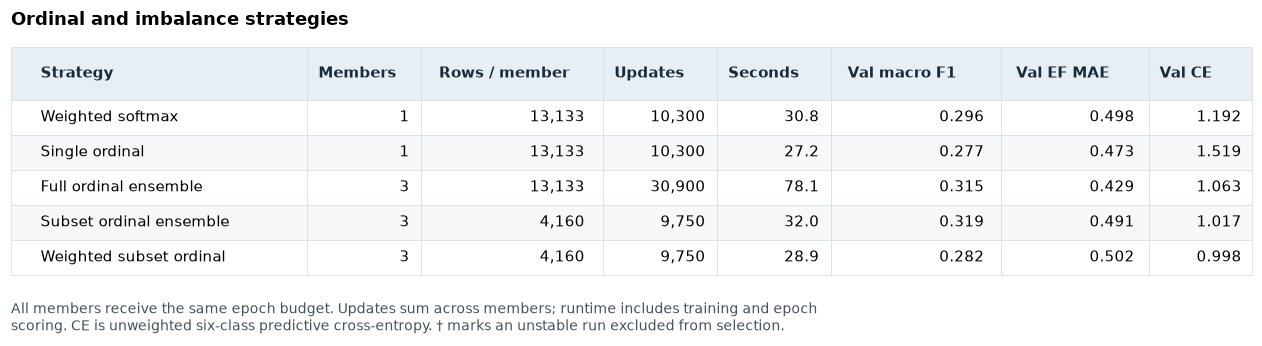

**Table 3.** Final-epoch validation results on the same holdout. Full ensembles isolate ensembling; subset ensembles additionally change training sampling.

**Saved — Ordinal and imbalance strategies:** [table_03_strategy_comparison.png](assets/tables/table_03_strategy_comparison.png) · [table_03_strategy_comparison.svg](assets/tables/table_03_strategy_comparison.svg) · [table_03_strategy_comparison.csv](data/results/experiments/table_03_strategy_comparison.csv)

**Selected strategy: Subset ordinal ensemble.** Freeze its formulation, member seeds, subsets, and weighting for the modeling question.

In [23]:
strategy_results = {strategy_configs[0].name: results[strategy_configs[0].name]}
for config in strategy_configs[1:]:
    strategy_results[config.name] = run(config, stage="Strategy")

strategy_rows = []
for name, result in strategy_results.items():
    final = result.epochs.iloc[-1]
    strategy_rows.append(
        {
            "Strategy": name + ("" if result.completed else "†"),
            "Members": result.config.members,
            "Rows / member": result.members[0]["training_rows"],
            "Updates": sum(int(member["optimizer_steps"]) for member in result.members),
            "Seconds": result.seconds,
            "Val macro F1": final.validation_macro_f1,
            "Val EF MAE": final.validation_ef_mae,
            "Val CE": final.validation_cross_entropy,
        }
    )
strategy_comparison = pd.DataFrame(strategy_rows)
save_table(
    strategy_comparison,
    "table_03_strategy_comparison",
    "Ordinal and imbalance strategies",
    caption="**Table 3.** Final-epoch validation results on the same holdout. "
    "Full ensembles isolate ensembling; subset ensembles additionally change training sampling.",
    formats={
        "Members": "d",
        "Rows / member": ",d",
        "Updates": ",d",
        "Seconds": ".1f",
        "Val macro F1": ".3f",
        "Val EF MAE": ".3f",
        "Val CE": ".3f",
    },
    width=12,
    results_dir=EXPERIMENT_DIR,
    note="All members receive the same epoch budget. Updates sum across members; runtime includes "
    "training and epoch scoring. CE is unweighted six-class predictive cross-entropy. "
    "† marks an unstable run excluded from selection.",
)
strategy_selected = choose_result(list(strategy_results.values()))
display(
    Markdown(
        f"**Selected strategy: {strategy_selected.config.name}.** "
        "Freeze its formulation, member seeds, subsets, and weighting for the modeling question."
    )
)

### Modeling question

In [24]:
modeling_results = {"Baseline": strategy_selected}
modeling_configs = [
    replace(strategy_selected.config, name="SGD-1", optimizer="SGD", learning_rate=0.1),
    replace(strategy_selected.config, name="SGD-2", optimizer="SGD", learning_rate=0.01),
    replace(strategy_selected.config, name="SGD-3", optimizer="SGD", learning_rate=0.001),
    replace(strategy_selected.config, name="L2", l2=0.001),
    replace(strategy_selected.config, name="Dropout-1", dropout=0.2),
    replace(strategy_selected.config, name="Dropout-2", dropout=0.5),
]
for config in modeling_configs:
    modeling_results[config.name] = run(config, stage="Modeling")

# Corresponding members start identically and see identical samples in every controlled run.
for result in modeling_results.values():
    for reference, member in zip(
        strategy_selected.members[: len(result.members)], result.members, strict=True
    ):
        for key in (
            "seed",
            "class_counts",
            "class_weights",
            "sample_sha256",
            "initial_weights_sha256",
        ):
            assert member[key] == reference[key], (result.config.name, key)

selected = choose_result(list(modeling_results.values()))
display(
    Markdown(
        f"**Selected training configuration: {selected.config.name}.** "
        "Retrain this approach for feature comparisons and the onset analysis."
    )
)

**SGD-1:** 3 member(s), 50/50 epochs; validation macro F1 **0.314**; completed.

**SGD-2:** 3 member(s), 50/50 epochs; validation macro F1 **0.202**; completed.

**SGD-3:** 3 member(s), 50/50 epochs; validation macro F1 **0.112**; completed.

**L2:** 3 member(s), 50/50 epochs; validation macro F1 **0.325**; completed.

**Dropout-1:** 3 member(s), 50/50 epochs; validation macro F1 **0.324**; completed.

**Dropout-2:** 3 member(s), 50/50 epochs; validation macro F1 **0.298**; completed.

**Selected training configuration: L2.** Retrain this approach for feature comparisons and the onset analysis.

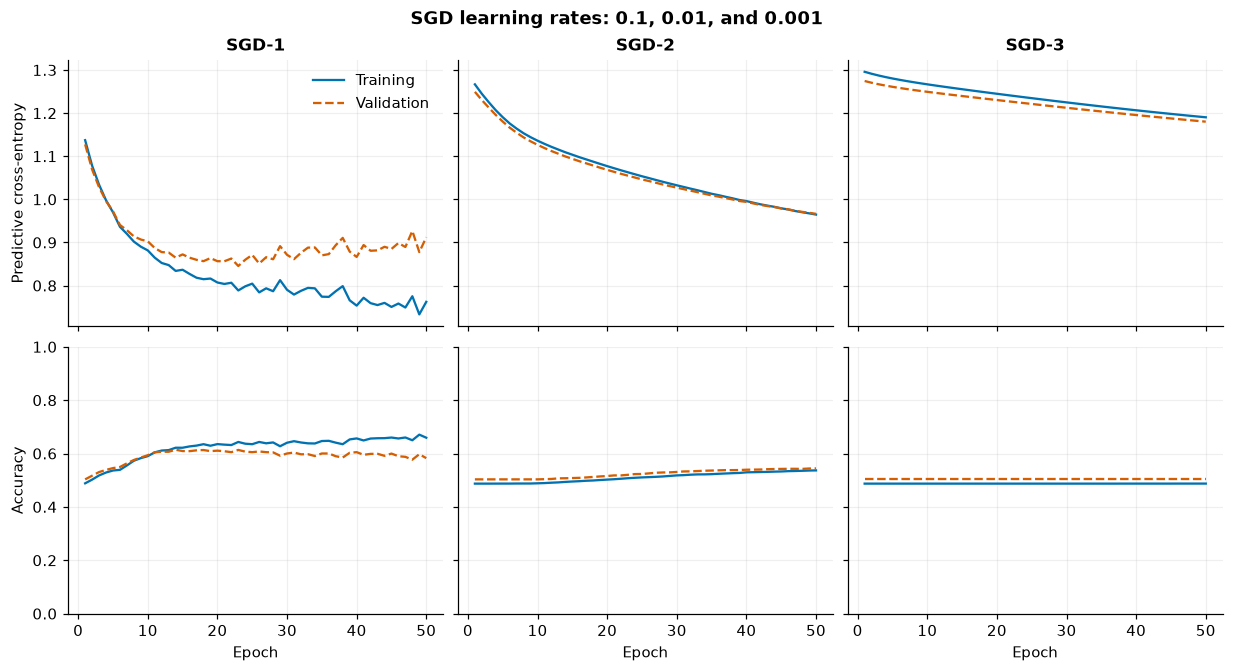

**Figure 5.** SGD comparisons using the selected strategy. Curves score member-averaged class probabilities on the full original cohorts, with dropout off. Corresponding member initialization and training subsets are matched across runs.

**Saved — figure:** [fig_05_sgd_learning_curves.png](assets/figures/fig_05_sgd_learning_curves.png) · [fig_05_sgd_learning_curves.svg](assets/figures/fig_05_sgd_learning_curves.svg)

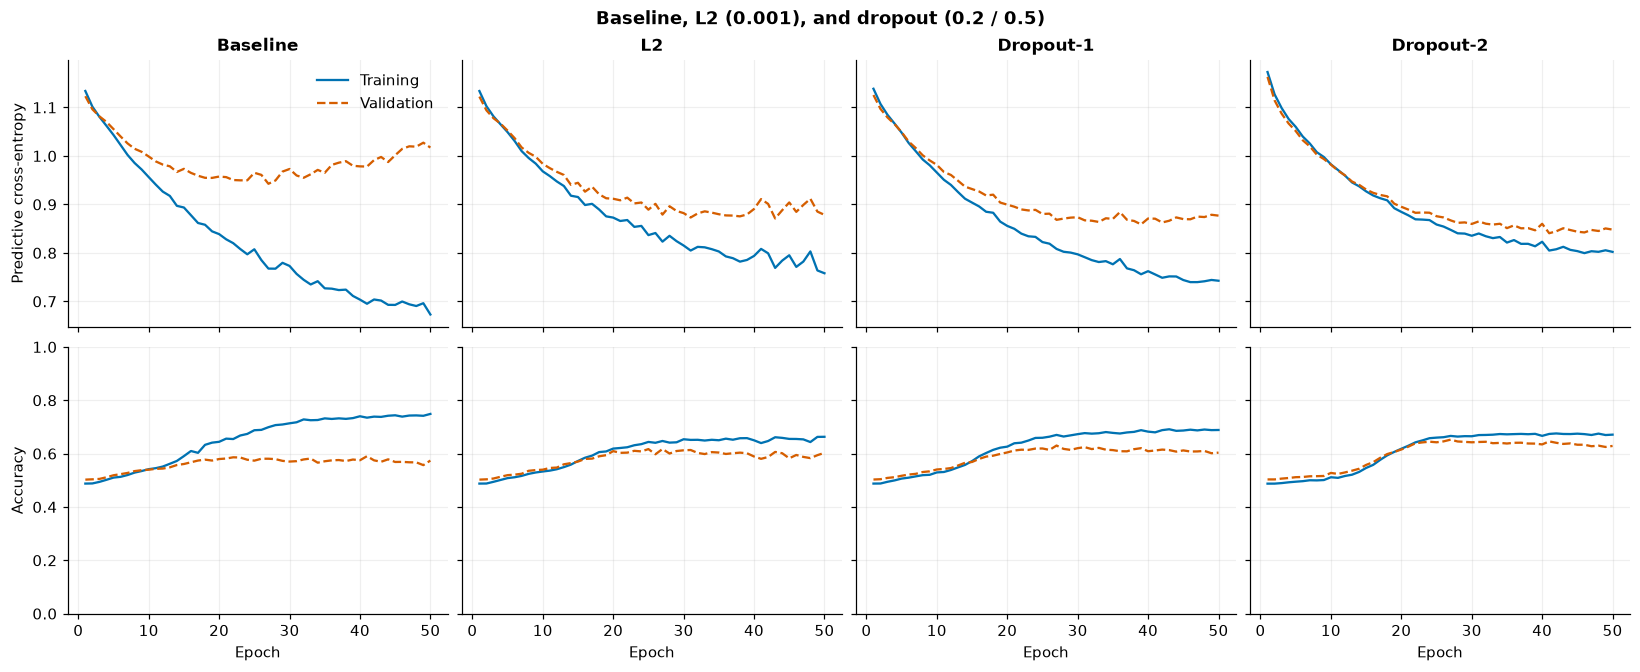

**Figure 6.** Matched Adam runs using the selected strategy. Predictive cross-entropy excludes weighting and L2 penalties; accuracy and CE use dropout-off probabilities. L2 and dropout are tested separately.

**Saved — figure:** [fig_06_regularization_learning_curves.png](assets/figures/fig_06_regularization_learning_curves.png) · [fig_06_regularization_learning_curves.svg](assets/figures/fig_06_regularization_learning_curves.svg)

In [25]:
fig = plot_learning_curves(
    modeling_results, ["SGD-1", "SGD-2", "SGD-3"], title="SGD learning rates: 0.1, 0.01, and 0.001"
)
show_figure(
    fig,
    "fig_05_sgd_learning_curves",
    "**Figure 5.** SGD comparisons using the selected strategy. Curves score "
    "member-averaged class probabilities on the full original cohorts, with dropout off. "
    "Corresponding member initialization and training subsets are matched across runs.",
)
fig = plot_learning_curves(
    modeling_results,
    ["Baseline", "L2", "Dropout-1", "Dropout-2"],
    title="Baseline, L2 (0.001), and dropout (0.2 / 0.5)",
)
show_figure(
    fig,
    "fig_06_regularization_learning_curves",
    "**Figure 6.** Matched Adam runs using the selected strategy. Predictive cross-entropy "
    "excludes weighting and L2 penalties; accuracy and CE use dropout-off probabilities. "
    "L2 and dropout are tested separately.",
)

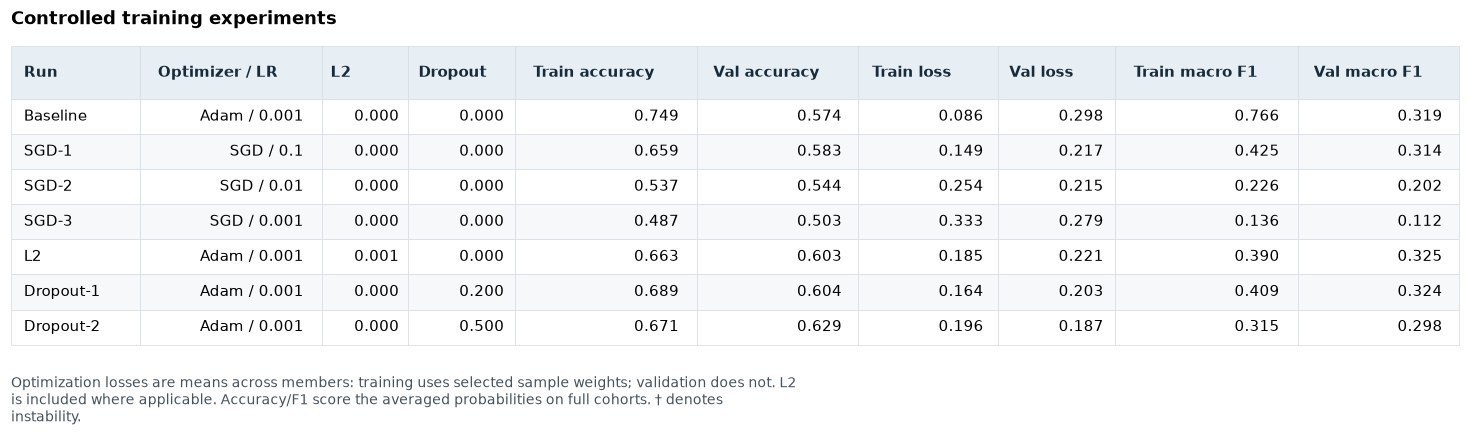

**Table 4.** Seven controlled comparisons using the selected strategy. The baseline reuses its completed strategy run.

**Saved — Controlled training experiments:** [table_04_training_experiments.png](assets/tables/table_04_training_experiments.png) · [table_04_training_experiments.svg](assets/tables/table_04_training_experiments.svg) · [table_04_training_experiments.csv](data/results/experiments/table_04_training_experiments.csv)

In [26]:
comparison = pd.DataFrame(
    [
        {
            "Run": name + ("" if result.completed else "†"),
            "Optimizer / LR": f"{result.config.optimizer} / {result.config.learning_rate:g}",
            "L2": result.config.l2,
            "Dropout": result.config.dropout,
            "Train accuracy": result.epochs.iloc[-1].train_accuracy,
            "Val accuracy": result.epochs.iloc[-1].validation_accuracy,
            "Train loss": result.epochs.iloc[-1].loss,
            "Val loss": result.epochs.iloc[-1].val_loss,
            "Train macro F1": result.epochs.iloc[-1].train_macro_f1,
            "Val macro F1": result.epochs.iloc[-1].validation_macro_f1,
        }
        for name, result in modeling_results.items()
    ]
)
save_table(
    comparison,
    "table_04_training_experiments",
    "Controlled training experiments",
    caption="**Table 4.** Seven controlled comparisons using the selected strategy. "
    "The baseline reuses its completed strategy run.",
    formats={column: ".3f" for column in comparison.columns[2:]},
    width=14,
    note="Optimization losses are means across members: training uses selected sample "
    "weights; validation does not. L2 is included where applicable. "
    "Accuracy/F1 score the averaged probabilities on full cohorts. † denotes instability.",
    results_dir=EXPERIMENT_DIR,
)

### Primary question

In [27]:
# Feature-wise imputation/scaling are already fitted on training only; remove columns and indicators.
removed_groups = {
    "Without radar": ["Onset radar", "Full-window radar"],
    "Without final track": ["Final track"],
    "Without land cover": ["Land cover"],
    "Without track or land cover": ["Final track", "Land cover"],
}
research_results = {"Full retrospective": selected}
research_columns = {"Full retrospective": X["Retrospective"]["train"].columns.tolist()}
for name, groups in removed_groups.items():
    excluded = {column for group in groups for column in feature_groups[group]}
    excluded |= {f"missingindicator_{column}" for column in list(excluded)}
    columns = [column for column in X["Retrospective"]["train"].columns if column not in excluded]
    assert len(columns) < X["Retrospective"]["train"].shape[1]
    research_columns[name] = columns
    research_results[name] = run(
        replace(selected.config, name=name), stage="Primary", columns=columns
    )

**Without radar:** 3 member(s), 50/50 epochs; validation macro F1 **0.337**; completed.

**Without final track:** 3 member(s), 50/50 epochs; validation macro F1 **0.229**; completed.

**Without land cover:** 3 member(s), 50/50 epochs; validation macro F1 **0.327**; completed.

**Without track or land cover:** 3 member(s), 50/50 epochs; validation macro F1 **0.220**; completed.

### Secondary question

Onset predictors remain conditional on cataloged onset and location and an assumed
five-minute radar latency; actual real-time receipt is unverified. This comparison
measures information available under that cutoff, not operational forecasting skill.

In [28]:
onset_result = run(replace(selected.config, name="Onset"), stage="Secondary", view="Onset")
research_results["Onset"] = onset_result
research_columns["Onset"] = X["Onset"]["train"].columns.tolist()

**Onset:** 3 member(s), 50/50 epochs; validation macro F1 **0.206**; completed.

### Experiment comparison

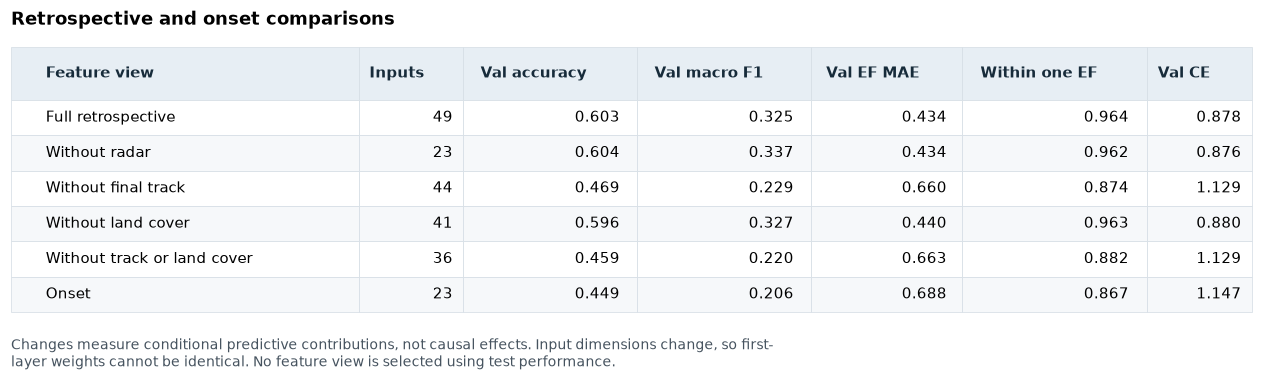

**Table 5.** Retrained feature comparisons using the selected training approach and identical event assignments. Full retrospective reuses the selected model.

**Saved — Retrospective and onset comparisons:** [table_05_research_comparison.png](assets/tables/table_05_research_comparison.png) · [table_05_research_comparison.svg](assets/tables/table_05_research_comparison.svg) · [table_05_research_comparison.csv](data/results/experiments/table_05_research_comparison.csv)

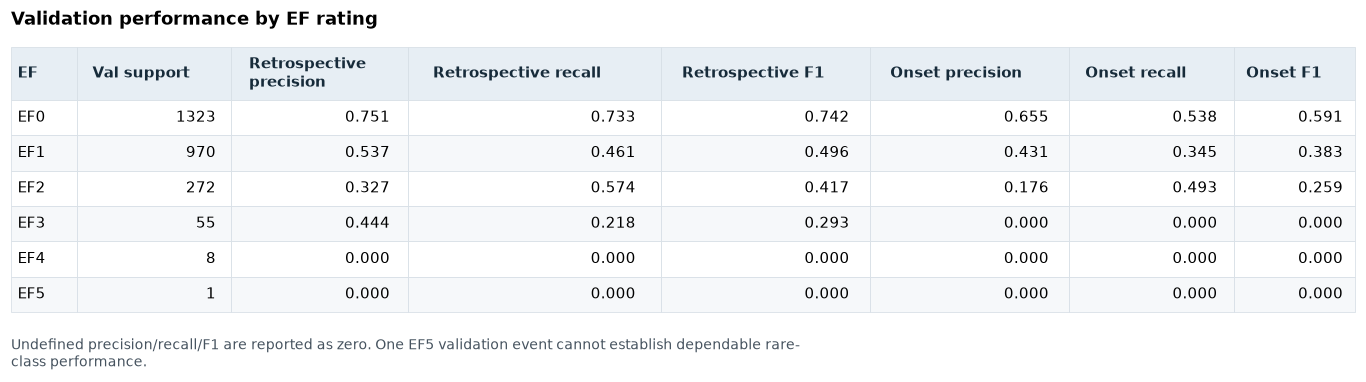

**Table 6.** Per-class validation results for the selected retrospective approach and its onset counterpart.

**Saved — Validation performance by EF rating:** [table_06_validation_by_class.png](assets/tables/table_06_validation_by_class.png) · [table_06_validation_by_class.svg](assets/tables/table_06_validation_by_class.svg) · [table_06_validation_by_class.csv](data/results/experiments/table_06_validation_by_class.csv)

In [29]:
research_comparison = pd.DataFrame(
    [
        {
            "Feature view": name + ("" if result.completed else "†"),
            "Inputs": len(research_columns[name]),
            "Val accuracy": result.epochs.iloc[-1].validation_accuracy,
            "Val macro F1": result.epochs.iloc[-1].validation_macro_f1,
            "Val EF MAE": result.epochs.iloc[-1].validation_ef_mae,
            "Within one EF": result.epochs.iloc[-1].validation_within_one,
            "Val CE": result.epochs.iloc[-1].validation_cross_entropy,
        }
        for name, result in research_results.items()
    ]
)
save_table(
    research_comparison,
    "table_05_research_comparison",
    "Retrospective and onset comparisons",
    caption="**Table 5.** Retrained feature comparisons using the selected training approach "
    "and identical event assignments. Full retrospective reuses the selected model.",
    formats={"Inputs": "d", **{column: ".3f" for column in research_comparison.columns[2:]}},
    width=12,
    note="Changes measure conditional predictive contributions, not causal effects. "
    "Input dimensions change, so first-layer weights cannot be identical. "
    "No feature view is selected using test performance.",
    results_dir=EXPERIMENT_DIR,
)

class_comparison = pd.DataFrame(
    {
        "EF": CLASS_NAMES,
        "Val support": np.bincount(training_labels["validation"], minlength=N_CLASSES),
    }
)
for view, result in [("Retrospective", selected), ("Onset", onset_result)]:
    if not result.completed:
        display(Markdown(f"**{view}:** unstable run; no per-class summary or checkpoint."))
        continue
    probabilities = ensemble_probabilities(result, X[view]["validation"].to_numpy(dtype="float32"))
    precision, recall, f1, _ = precision_recall_fscore_support(
        training_labels["validation"],
        probabilities.argmax(axis=1),
        labels=range(N_CLASSES),
        zero_division=0,
    )
    for metric, values in [("precision", precision), ("recall", recall), ("F1", f1)]:
        class_comparison[f"{view} {metric}"] = values
save_table(
    class_comparison,
    "table_06_validation_by_class",
    "Validation performance by EF rating",
    caption="**Table 6.** Per-class validation results for the selected retrospective "
    "approach and its onset counterpart.",
    formats={"Val support": "d", **{c: ".3f" for c in class_comparison.columns[2:]}},
    width=13,
    note="Undefined precision/recall/F1 are reported as zero. "
    "One EF5 validation event cannot establish dependable rare-class performance.",
    results_dir=EXPERIMENT_DIR,
)

In [30]:
# Persist each physical run once; reused baselines are references, not additional training.
epoch_frames, member_frames, summary_rows = [], [], []
for name, result in results.items():
    settings = asdict(result.config)
    details = run_details[name]
    epoch_frames.append(
        result.epochs.assign(
            run=name, stage=details["stage"], **{k: v for k, v in settings.items() if k != "name"}
        )
    )
    member_frames.append(result.member_epochs.assign(run=name, stage=details["stage"]))
    summary_rows.append(
        {
            "run": name,
            **details,
            **settings,
            "completed": result.completed,
            "seconds": result.seconds,
            "optimizer_updates": sum(int(m["optimizer_steps"]) for m in result.members),
            **result.epochs.iloc[-1].to_dict(),
        }
    )
pd.concat(epoch_frames, ignore_index=True).to_csv(
    EXPERIMENT_DIR / "training_history.csv", index=False
)
pd.concat(member_frames, ignore_index=True).to_csv(
    EXPERIMENT_DIR / "member_history.csv", index=False
)
pd.DataFrame(summary_rows).drop(columns="input_columns").to_csv(
    EXPERIMENT_DIR / "experiment_summary.csv", index=False
)

sampling_rows = []
for sampling in ("full", "partial"):
    for member in range(ENSEMBLE_MEMBERS):
        positions = sample_training_rows(
            training_labels["train"], sampling=sampling, seed=SEED + 1000 * member
        )
        sampling_rows.extend(
            {"sampling": sampling, "member": member, ID: y["train"].index[position]}
            for position in positions
        )
pd.DataFrame(sampling_rows).to_parquet(EXPERIMENT_DIR / "training_membership.parquet", index=False)
manifest = {
    "seed": SEED,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "ensemble_members": ENSEMBLE_MEMBERS,
    "partial_sampling": "cap EF0/EF1 at training EF2 count; retain every EF2–EF5 record",
    "sqrt_weighting": "sampled class count ** -0.5, normalized to mean training sample weight one",
    "selection": "final validation macro F1 descending, then six-class predictive CE ascending",
    "strategy_selected": strategy_selected.config.name,
    "training_selected": selected.config.name,
    "modeling_baseline_reuses": strategy_selected.config.name,
    "primary_reference_reuses": selected.config.name,
    "probability_rule": "mean six-class probabilities across members; argmax for EF category",
    "test_scored": False,
    "runs": {
        name: {
            "config": asdict(result.config),
            **run_details[name],
            "completed": result.completed,
            "members": result.members,
        }
        for name, result in results.items()
    },
}
save_json(manifest, EXPERIMENT_DIR / "experiment_manifest.json")
show_saved(
    f"{len(results)} experiments: epoch metrics, member losses, costs, and final summaries",
    EXPERIMENT_DIR / "training_history.csv",
    EXPERIMENT_DIR / "member_history.csv",
    EXPERIMENT_DIR / "experiment_summary.csv",
)
show_saved(
    "training-only member assignments and complete experiment settings",
    EXPERIMENT_DIR / "training_membership.parquet",
    EXPERIMENT_DIR / "experiment_manifest.json",
)

for view, result in [("Retrospective", selected), ("Onset", onset_result)]:
    if not result.completed:
        continue
    checkpoint = MODEL_DIR / f"selected_{view.lower()}.keras"
    exported = inference_model(result, X[view]["train"].shape[1])
    exported.save(checkpoint)
    metadata_path = MODEL_DIR / f"selected_{view.lower()}.json"
    save_json(
        {
            "config": asdict(result.config),
            "input_columns": X[view]["train"].columns.tolist(),
            "classes": CLASS_NAMES,
            "outputs": "six EF class probabilities",
            "preprocessor": f"data/derived/{view.lower()}_preprocessor.joblib",
            "custom_objects": "execute the Section 5 ordinal helper definitions before loading",
            "selection_basis": "retrospective validation strategy and controlled comparisons",
            "test_scored": False,
        },
        metadata_path,
    )
    show_saved(
        f"{view} final-epoch probability model and input definition", checkpoint, metadata_path
    )

display(
    Markdown(
        f"**Selected approach:** {strategy_selected.config.name}, with **{selected.config.name}** "
        f"training settings. Retrospective validation macro F1: "
        f"**{selected.epochs.iloc[-1].validation_macro_f1:.3f}**; onset: "
        f"**{onset_result.epochs.iloc[-1].validation_macro_f1:.3f}**. "
        "The ordinal/subset combination is a candidate, not a predetermined winner. "
        "The holdout has guided several comparisons; rankings remain exploratory until final testing."
    )
)

**Saved — 16 experiments: epoch metrics, member losses, costs, and final summaries:** [training_history.csv](data/results/experiments/training_history.csv) · [member_history.csv](data/results/experiments/member_history.csv) · [experiment_summary.csv](data/results/experiments/experiment_summary.csv)

**Saved — training-only member assignments and complete experiment settings:** [training_membership.parquet](data/results/experiments/training_membership.parquet) · [experiment_manifest.json](data/results/experiments/experiment_manifest.json)

**Saved — Retrospective final-epoch probability model and input definition:** [selected_retrospective.keras](data/models/selected_retrospective.keras) · [selected_retrospective.json](data/models/selected_retrospective.json)

**Saved — Onset final-epoch probability model and input definition:** [selected_onset.keras](data/models/selected_onset.keras) · [selected_onset.json](data/models/selected_onset.json)

**Selected approach:** Subset ordinal ensemble, with **L2** training settings. Retrospective validation macro F1: **0.325**; onset: **0.206**. The ordinal/subset combination is a candidate, not a predetermined winner. The holdout has guided several comparisons; rankings remain exploratory until final testing.

## 6. Final Evaluation

Evaluate the selected retrospective and onset models once on the held-out test set.
Report accuracy, six-class predictive cross-entropy, macro F1, per-class
precision/recall/F1 and support, confusion matrices, mean absolute EF-category error,
and within-one-category accuracy. Keep all six labels in every summary.

Do not use test results to revise the strategy, training settings, or feature selection.
Temporal splitting, additional seed repetitions, and focal ordinal loss remain separate
follow-up analyses; none changes the completed controlled comparisons.

## 7. Findings and Limitations

Answer the **primary question**, **secondary question**, and **modeling question**.
Distinguish ordering, sampling, weighting, and ensembling effects, including their
training costs. Discuss rare-class uncertainty, unknown labels, missingness, source
linkage, and temporal transfer. Repeated use of the same rare examples in ensemble
members does not create independent evidence. Interpret feature contributions as
associations; disagreement alone does not establish causation or an incorrect EF rating.